# NDTA 631 – Data Analysis and Visualisation

## Group Assignment 2026

### South African Dataset Analysis
- Dataset1: AgriConnect Indicators
- Dataset2:Interest Margin to gross income(Core FSI)


Group Members:
- Reneilwe Morajane – 202112110
- Leah Marumo Machaka – 202464717
- Amogelang Maine – 202409912
- Mhlengie Prince Ngwenya – 202401141
- Miranda Nkonwana– 202438359
- MK Khosa – 202401364

# Introduction 

South Africa plays an important role in the regional economy, including agriculture, trade and finance. Changes in financial conditions can affect the cost of borrowing for businesses and households. This makes it useful to ask whether changes in South Africa's borrowing-cost environment occur alongside changes in farming activity across the wider Sub-Saharan African region. 

This report investigates a simple question: when South Africa's Interest Margin to Gross Income is higher, does agricultural activity in the surrounding region look weaker in the same year? Farming activity is represented mainly by inorganic fertilizer use and agricultural market participation.

## Importing Python Libraries

In [38]:
import pandas as pd
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


# PART 1 — DATASET 1 ( AgriConnect Indicators)

### Load data

In [48]:
agri = pd.read_csv("AgriConnect_Indicators.csv")

income = pd.read_csv("Interest_margin_to_gross_income.csv")
income



,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,FINANCIAL_SECTOR,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE,...,UNIT_MEASURE_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL,DERIVATION_TYPE_LABEL
0,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2009,69.051442,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
1,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2010,66.750153,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
2,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2011,65.101696,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
3,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2012,65.710860,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
4,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2013,69.549851,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15732,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2023-Q4,91.019787,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
15733,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2024-Q1,89.998412,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
15734,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2024-Q2,90.202866,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
15735,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2024-Q3,90.109772,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)


##  DATA PREPARATION

###  DATASET 1 ( AgriConnect Indicators)

In [49]:
agri

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,KEN,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MLI,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,NER,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SEN,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,TGO,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZWE,AG_HS_CT,_Z,_Z,_Z,HA,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
153,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,_T,AG_IRG_CT,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
154,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,BEN,AG_IRG_CT,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
155,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,BFA,AG_IRG_CT,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public


## Analyzing the Data

The main goal of data understanding is to gain general insights about the data, which covers the number of rows and columns, values in the data, datatypes, and Missing values in the dataset.

- shape – shape will display the number of observations(rows) and features(columns) in the dataset
- head() will display the top 5 observations of the dataset 
- tail() will display the last 5 observations of the dataset 
- info() shows the variables that  have missing values.
(LEAH)

In [4]:
agri.shape

(157, 43)

In [5]:
agri.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,KEN,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MLI,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,NER,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SEN,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,TGO,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public


In [50]:
agri.tail()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
152,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZWE,AG_HS_CT,_Z,_Z,_Z,HA,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
153,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,_T,AG_IRG_CT,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
154,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,BEN,AG_IRG_CT,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
155,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,BFA,AG_IRG_CT,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
156,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,CAF,AG_IRG_CT,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public


In [7]:
agri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 43 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   STRUCTURE               157 non-null    object 
 1   STRUCTURE_ID            157 non-null    object 
 2   ACTION                  157 non-null    object 
 3   FREQ                    157 non-null    object 
 4   REF_AREA                157 non-null    object 
 5   INDICATOR               157 non-null    object 
 6   SEX                     157 non-null    object 
 7   AGE                     157 non-null    object 
 8   URBANISATION            157 non-null    object 
 9   UNIT_MEASURE            157 non-null    object 
 10  COMP_BREAKDOWN_1        157 non-null    object 
 11  COMP_BREAKDOWN_2        157 non-null    object 
 12  COMP_BREAKDOWN_3        157 non-null    object 
 13  TIME_PERIOD             157 non-null    int64  
 14  OBS_VALUE               157 non-null    fl

# Data Cleaning

#### Clean column names

In [8]:
agri.columns = (
    agri.columns
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
)

print(agri.columns.tolist())

['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'OBS_VALUE', 'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'COMMENT_TS', 'COMMENT_OBS', 'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL']


#### Checking of unique values in the dataset

In [9]:
unique_values = agri.nunique()

display(unique_values)

STRUCTURE                   1
STRUCTURE_ID                1
ACTION                      1
FREQ                        1
REF_AREA                   35
INDICATOR                   7
SEX                         1
AGE                         1
URBANISATION                1
UNIT_MEASURE                4
COMP_BREAKDOWN_1            1
COMP_BREAKDOWN_2            1
COMP_BREAKDOWN_3            1
TIME_PERIOD                15
OBS_VALUE                 145
AGG_METHOD                  1
UNIT_TYPE                   1
DECIMALS                    1
DATABASE_ID                 1
TIME_FORMAT                 1
COMMENT_TS                 21
COMMENT_OBS               127
UNIT_MULT                   1
OBS_STATUS                  1
OBS_CONF                    1
FREQ_LABEL                  1
REF_AREA_LABEL             35
INDICATOR_LABEL             7
SEX_LABEL                   1
AGE_LABEL                   1
URBANISATION_LABEL          1
UNIT_MEASURE_LABEL          4
COMP_BREAKDOWN_1_LABEL      1
COMP_BREAK

In [10]:
total_unique = agri.nunique().sum()

print("Total unique values:", total_unique)

Total unique values: 433


#### Selecting Relevant Indicators

In [11]:
print("Available AgriConnect indicators:")
print(agri["INDICATOR_LABEL"].unique().tolist())


relevant_agri_indicators = [
    "Market participation - Percentage of Agricultural Households Selling Any Production",
    "Average Sold Percentage of Household Agricultural Production",
    "Percentage of Agricultural Households using Inorganic Fertilizer",
    "Percentage of Agricultural Households using Improved Seeds",
    "Percentage of Agricultural Households using Irrigation",
    "Median Agricultural Household Cultivated Area",
    "Median Agricultural Household Production Value",
]

agri = agri[agri["INDICATOR_LABEL"].isin(relevant_agri_indicators)].copy()
print("\nRows after selecting relevant indicators:", agri.shape)

Available AgriConnect indicators:
['Average Sold Percentage of Household Agricultural Production', 'Percentage of Agricultural Households using Inorganic Fertilizer', 'Median Agricultural Household Production Value', 'Percentage of Agricultural Households using Improved Seeds', 'Market participation - Percentage of Agricultural Households Selling Any Production', 'Percentage of Agricultural Households using Irrigation', 'Median Agricultural Household Cultivated Area']

Rows after selecting relevant indicators: (157, 43)


#### Filtering for South Africa

In [12]:
sa_agri = agri[agri["REF_AREA"] == "ZAF"]
print(f"AgriConnect rows for South Africa (ZAF): {len(sa_agri)}")

AgriConnect rows for South Africa (ZAF): 0


South Africa returns **0 rows** in AgriConnect Indicators - South Africa is not part of this survey programme (it is a household-level agricultural survey run across lower-income Sub-Saharan African economies; South Africa's agricultural sector is instead tracked through other World Bank/Stats SA series). This is confirmed directly above rather than assumed.

Because of this, AgriConnect is used in this report as **regional Sub-Saharan African context** - the 34 countries it does cover act as a peer-economy benchmark against which South Africa's own banking-sector story (Interest Margin to Gross Income, filtered to `ZAF` below and throughout Part 3) is compared. The two datasets are still genuinely merged on a shared `year` key later in Part 3 (Section 3.5), which is possible precisely because AgriConnect is left at full regional coverage rather than filtered down to an empty South African subset.

## Handling Missing Values

The dataset was examined for missing values and non-applicable entries. The variables `SEX_LABEL`, `AGE_LABEL`, and `URBANISATION_LABEL` contain "Not applicable" for all 157 observations. These values represent dimensions that are not applicable to this particular dataset rather than missing observations, so they were retained and not treated as missing values.

#### missing values in each column

In [13]:
for column in agri.columns:
    if agri[column].astype(str).str.lower().str.contains("not applicable", na=False).any():
        print(column)
import numpy as np

agri = agri.replace(
    ["Not applicable", "N/A", "NA", ".."],
    np.nan
)        

SEX_LABEL
AGE_LABEL
URBANISATION_LABEL
COMP_BREAKDOWN_1_LABEL
COMP_BREAKDOWN_2_LABEL
COMP_BREAKDOWN_3_LABEL
AGG_METHOD_LABEL


In [14]:

missing_values = agri.isnull().sum()

display(missing_values)

STRUCTURE                   0
STRUCTURE_ID                0
ACTION                      0
FREQ                        0
REF_AREA                    0
INDICATOR                   0
SEX                         0
AGE                         0
URBANISATION                0
UNIT_MEASURE                0
COMP_BREAKDOWN_1            0
COMP_BREAKDOWN_2            0
COMP_BREAKDOWN_3            0
TIME_PERIOD                 0
OBS_VALUE                   0
AGG_METHOD                  0
UNIT_TYPE                   0
DECIMALS                    0
DATABASE_ID                 0
TIME_FORMAT                 0
COMMENT_TS                  0
COMMENT_OBS                 0
UNIT_MULT                   0
OBS_STATUS                  0
OBS_CONF                    0
FREQ_LABEL                  0
REF_AREA_LABEL              0
INDICATOR_LABEL             0
SEX_LABEL                 157
AGE_LABEL                 157
URBANISATION_LABEL        157
UNIT_MEASURE_LABEL          0
COMP_BREAKDOWN_1_LABEL      0
COMP_BREAK

In [15]:

print("Total missing values:", agri.isnull().sum().sum())

Total missing values: 471


### Drop the columns that have missing and no usable information.After removal, no missing values remained.

In [16]:
agri = agri.drop(
    columns=["SEX_LABEL", "AGE_LABEL", "URBANISATION_LABEL"]
)

print("Total missing values:", agri.isnull().sum().sum())

Total missing values: 0


## Duplicate Values

In [17]:
print("Duplicate rows before cleaning:", agri.duplicated().sum())

agri = agri.drop_duplicates()

Duplicate rows before cleaning: 0


In [18]:
print("Duplicate rows after cleaning:", agri.duplicated().sum())

Duplicate rows after cleaning: 0


## Final cleaning check

In [19]:
print("Final dataset shape:", agri.shape)
print("Duplicate rows:", agri.duplicated().sum())
print("Total missing values:", agri.isnull().sum().sum())

display(agri.head())

Final dataset shape: (157, 40)
Duplicate rows: 0
Total missing values: 0


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,KEN,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MLI,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,NER,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SEN,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,TGO,AG_SD_HH_PD,_Z,_Z,_Z,PT,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,AgriConnect Indicators,CCYY,Units,Normal value,Public


### Dataset 2 — Interest Margin

In [20]:

income


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,FINANCIAL_SECTOR,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE,...,UNIT_MEASURE_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL,DERIVATION_TYPE_LABEL
0,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2009,69.051442,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
1,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2010,66.750153,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
2,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2011,65.101696,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
3,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2012,65.710860,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
4,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2013,69.549851,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15732,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2023-Q4,91.019787,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
15733,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2024-Q1,89.998412,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
15734,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2024-Q2,90.202866,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
15735,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2024-Q3,90.109772,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)


## Analyzing the Data
- shape – shape will display the number of observations(rows) and features(columns) in the dataset
- head() will display the top 5 observations of the dataset 
- tail() will display the last 5 observations of the dataset 
- info() shows the variables that  have missing values.

In [21]:
income.shape

(15737, 33)

In [22]:
income.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,FINANCIAL_SECTOR,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE,...,UNIT_MEASURE_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL,DERIVATION_TYPE_LABEL
0,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2009,69.051442,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
1,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2010,66.750153,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
2,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2011,65.101696,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
3,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2012,65.710860,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
4,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,A,MUS,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2013,69.549851,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)


In [23]:
income.tail()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,FINANCIAL_SECTOR,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE,...,UNIT_MEASURE_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL,DERIVATION_TYPE_LABEL
15732,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2023-Q4,91.019787,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
15733,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2024-Q1,89.998412,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
15734,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2024-Q2,90.202866,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
15735,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2024-Q3,90.109772,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)
15736,datastructure,WB.DEC.DG:DS_IMF_FSIC(1.0.0),I,Q,FSM,IMF_FSIC_FSI99_CFSI,S12CFSI,PT,2024-Q4,89.983936,...,Percentage,Not Applicable,Ratio,Two,"Financial Soundness Indicators (FSI), Core and...",CCYY,Units,Normal value,Public,IMF Staff calculations (derived value)


In [24]:
income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15737 entries, 0 to 15736
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   STRUCTURE               15737 non-null  object 
 1   STRUCTURE_ID            15737 non-null  object 
 2   ACTION                  15737 non-null  object 
 3   FREQ                    15737 non-null  object 
 4   REF_AREA                15737 non-null  object 
 5   INDICATOR               15737 non-null  object 
 6   FINANCIAL_SECTOR        15737 non-null  object 
 7   UNIT_MEASURE            15737 non-null  object 
 8   TIME_PERIOD             15737 non-null  object 
 9   OBS_VALUE               15737 non-null  float64
 10  AGG_METHOD              15737 non-null  object 
 11  UNIT_TYPE               15737 non-null  object 
 12  DECIMALS                15737 non-null  int64  
 13  DATABASE_ID             15737 non-null  object 
 14  TIME_FORMAT             15737 non-null

# Data Cleaning

#### Clean column names

In [25]:
income.columns = (
    income.columns
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
)

print(income.columns.tolist())

['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'FINANCIAL_SECTOR', 'UNIT_MEASURE', 'TIME_PERIOD', 'OBS_VALUE', 'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'DERIVATION_TYPE', 'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'FINANCIAL_SECTOR_LABEL', 'UNIT_MEASURE_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL', 'DERIVATION_TYPE_LABEL']


### Checking Unique Values in the Dataset

In [26]:
unique_values = income.nunique()

display(unique_values)

STRUCTURE                     1
STRUCTURE_ID                  1
ACTION                        1
FREQ                          3
REF_AREA                    154
INDICATOR                     1
FINANCIAL_SECTOR              1
UNIT_MEASURE                  1
TIME_PERIOD                 432
OBS_VALUE                 11727
AGG_METHOD                    1
UNIT_TYPE                     1
DECIMALS                      1
DATABASE_ID                   1
TIME_FORMAT                   1
UNIT_MULT                     1
OBS_STATUS                    1
OBS_CONF                      1
DERIVATION_TYPE               1
FREQ_LABEL                    3
REF_AREA_LABEL              154
INDICATOR_LABEL               1
FINANCIAL_SECTOR_LABEL        1
UNIT_MEASURE_LABEL            1
AGG_METHOD_LABEL              1
UNIT_TYPE_LABEL               1
DECIMALS_LABEL                1
DATABASE_ID_LABEL             1
TIME_FORMAT_LABEL             1
UNIT_MULT_LABEL               1
OBS_STATUS_LABEL              1
OBS_CONF

In [27]:
total_unique = income.nunique().sum()

print("Total unique values:", total_unique)

Total unique values: 12500


#### Selecting Relevant Columns

In [28]:

relevant_income_cols = [
    "REF_AREA", "REF_AREA_LABEL", "FREQ", "FREQ_LABEL",
    "FINANCIAL_SECTOR", "FINANCIAL_SECTOR_LABEL",
    "TIME_PERIOD", "OBS_VALUE",
]
income = income[relevant_income_cols].copy()
print("Columns retained:", income.columns.tolist())
print("Shape after column selection:", income.shape)

Columns retained: ['REF_AREA', 'REF_AREA_LABEL', 'FREQ', 'FREQ_LABEL', 'FINANCIAL_SECTOR', 'FINANCIAL_SECTOR_LABEL', 'TIME_PERIOD', 'OBS_VALUE']
Shape after column selection: (15737, 8)


 ['REF_AREA', 'REF_AREA_LABEL', 'FREQ', 'FREQ_LABEL', 'FINANCIAL_SECTOR', 'FINANCIAL_SECTOR_LABEL', 'TIME_PERIOD', 'OBS_VALUE']
Shape after column selection: (15737, 8)


#### Filtering for South Africa

In [29]:
sa_income = income[income["REF_AREA"] == "ZAF"]
print(f"Interest Margin rows for South Africa (ZAF): {len(sa_income)}")
print(sa_income["FREQ_LABEL"].value_counts())

Interest Margin rows for South Africa (ZAF): 262
FREQ_LABEL
Monthly      175
Quarterly     70
Annual        17
Name: count, dtype: int64


Unlike AgriConnect, South Africa **is** covered here - across Annual, Quarterly and Monthly frequencies, all for the Deposit Takers sector. This confirms Interest Margin to Gross Income is a genuine South African World Bank Data360 dataset for this analysis, and this `sa_income` subset (or the equivalent annual-only version built in Part 3) is the series used throughout the rest of the report.

# Handling Missing Values

#### missing values in each column

In [30]:
for column in income.columns:
    if income[column].astype(str).str.lower().str.contains("not applicable", na=False).any():
        print(column)
import numpy as np

income = income.replace(
    ["Not applicable", "N/A", "NA", ".."],
    np.nan
)     

In [31]:
missing_values = income.isnull().sum()

display(missing_values)

REF_AREA                  0
REF_AREA_LABEL            0
FREQ                      0
FREQ_LABEL                0
FINANCIAL_SECTOR          0
FINANCIAL_SECTOR_LABEL    0
TIME_PERIOD               0
OBS_VALUE                 0
dtype: int64

In [32]:
print("Total missing values:", income.isnull().sum().sum())

Total missing values: 0


## Duplicate Values

In [33]:
print("Duplicate rows before cleaning:", income.duplicated().sum())

income = income.drop_duplicates()

Duplicate rows before cleaning: 0


 0


## Final Cleaning Dataset Check

In [34]:
print("Final dataset shape:", income.shape)
print("Duplicate rows:", income.duplicated().sum())
print("Total missing values:", income.isnull().sum().sum())

display(income.head())

Final dataset shape: (15737, 8)
Duplicate rows: 0
Total missing values: 0


,REF_AREA,REF_AREA_LABEL,FREQ,FREQ_LABEL,FINANCIAL_SECTOR,FINANCIAL_SECTOR_LABEL,TIME_PERIOD,OBS_VALUE
0,MUS,Mauritius,A,Annual,S12CFSI,Deposit takers,2009,69.051442
1,MUS,Mauritius,A,Annual,S12CFSI,Deposit takers,2010,66.750153
2,MUS,Mauritius,A,Annual,S12CFSI,Deposit takers,2011,65.101696
3,MUS,Mauritius,A,Annual,S12CFSI,Deposit takers,2012,65.710860
4,MUS,Mauritius,A,Annual,S12CFSI,Deposit takers,2013,69.549851


# Descriptive Statistics and Insights




The AgriConnect dataset contains 157 observations. The `OBS_VALUE` variable has a mean of approximately 33.13 and a median of approximately 9.74. The mean is considerably higher than the median, suggesting that the distribution is positively skewed and may be influenced by some relatively high observations.

The values of `OBS_VALUE` range from approximately 0.045 to 443.327, indicating substantial variation in the indicator values. The standard deviation of approximately 58.97 is relatively large compared with the mean, further indicating considerable variability in the observations.

The middle 50% of observations fall between approximately 2.50 and 43.74, based on the first and third quartiles

In [35]:
agri.describe()

,TIME_PERIOD,OBS_VALUE,DECIMALS,TIME_FORMAT,UNIT_MULT
count,157.000000,157.000000,157.0,157.0,157.0
mean,2019.535032,33.127026,2.0,602.0,0.0
std,4.267541,58.966650,0.0,0.0,0.0
min,2004.000000,0.044586,2.0,602.0,0.0
25%,2017.000000,2.500000,2.0,602.0,0.0
50%,2021.000000,9.743613,2.0,602.0,0.0
75%,2022.000000,43.740500,2.0,602.0,0.0
max,2024.000000,443.327166,2.0,602.0,0.0


In [36]:
income.describe()

,OBS_VALUE
count,15737.000000
mean,61.936964
std,14.612201
min,-500.672411
25%,55.339889
50%,63.087369
75%,70.418065
max,218.534902


The Interest Margin to Gross Income (Core FSI) dataset contains 15,737 observations. The `OBS_VALUE` variable has a mean of 61.94 and a median of 63.09, indicating that the typical interest margin to gross income ratio is approximately 63%.

The standard deviation is 14.61, showing a moderate level of variation in the observations around the mean. The middle 50% of observations fall between 55.34 and 70.42, based on the first and third quartiles.

The observed values range from -500.67 to 218.53, indicating a very wide range. The minimum value is substantially below the main distribution and may represent an unusual observation or a special reporting situation that may require further investigation.

The mean is slightly lower than the median, suggesting that the distribution may be influenced by relatively low observations. Overall, most observations are concentrated around the 55% to 70% range, while the extreme minimum and maximum values indicate the presence of substantial variation in the dataset.

# PART 2 — NUMERICAL ANALYSIS (NUMPY)

## Section 2.1: Array Reshaping & Data Integrity
To evaluate cross-country agricultural indicators from Dataset 1 (AgriConnect_Indicators.csv), the long-format observations are pivoted into a wide-format country-by-indicator matrix (34 x 7). The continental "Overall" aggregate row (REF_AREA = `_T`) is excluded first, since it is a regional summary rather than an independent peer country and would otherwise bias the composite index and correlation results below.

We then perform array flattening and reconstruction to verify that NumPy array reshape operations preserve data integrity across missing (NaN) cells without data loss.

# Pivot to country-by-indicator matrix (rows: REF_AREA, cols: INDICATOR)

In [37]:
agri_countries = agri[agri["REF_AREA"] != "_T"].copy()  # drop continental "Overall" aggregate - not a peer country

agri_pivot = agri_countries.pivot_table(index="REF_AREA", columns="INDICATOR", values="OBS_VALUE", aggfunc="mean")
matrix_2d = agri_pivot.to_numpy(dtype=float)
print("Pivot shape (real countries only):", matrix_2d.shape)

Pivot shape (real countries only): (34, 7)



# Flatten and reconstruct to test reshape integrity

In [38]:


array_1d = matrix_2d.reshape(-1)
reshaped_2d = array_1d.reshape(matrix_2d.shape)



# Use allclose with equal_nan=True to allow NaN positions to match

In [39]:

is_equal = np.allclose(matrix_2d, reshaped_2d, equal_nan=True)

print("--- 2.1 Array Reshaping Verification ---")
print(f"Original 2D Matrix Shape  : {matrix_2d.shape}")
print(f"Flattened 1D Array Length : {array_1d.size}")
print(f"Reshape Integrity Preserved: {is_equal}")

--- 2.1 Array Reshaping Verification ---
Original 2D Matrix Shape  : (34, 7)
Flattened 1D Array Length : 238
Reshape Integrity Preserved: True


## Section 2.2: Trend Analysis — South Africa Interest Margin
Using the Interest Margin dataset, we filter for South Africa's annual time series (2008–2024).
We calculate a least-squares linear fit (np.polyfit) and Year-over-Year changes to summarise trend and volatility.

# Filter South Africa annual series (FREQ == 'A') and years likely numeric

In [40]:
sa_annual = income[(income['REF_AREA'] == 'ZAF') & (income['FREQ'] == 'A')].copy()
sa_annual = sa_annual.sort_values('TIME_PERIOD')  # ensure chronological order before any diff/trend calculations
print('SA annual rows:', len(sa_annual))
print(sa_annual.head(3).to_string(index=False))

SA annual rows: 17
REF_AREA REF_AREA_LABEL FREQ FREQ_LABEL FINANCIAL_SECTOR FINANCIAL_SECTOR_LABEL TIME_PERIOD  OBS_VALUE
     ZAF   South Africa    A     Annual          S12CFSI         Deposit takers        2008  50.289014
     ZAF   South Africa    A     Annual          S12CFSI         Deposit takers        2009  48.214878
     ZAF   South Africa    A     Annual          S12CFSI         Deposit takers        2010  47.302403


### Ensure TIME_PERIOD is integer when possible

In [41]:
sa_annual = sa_annual.dropna(subset=["TIME_PERIOD", "OBS_VALUE"])

years = sa_annual["TIME_PERIOD"].astype(int)
values = sa_annual["OBS_VALUE"].astype(float)

slope, intercept = np.polyfit(years, values, 1)
r2 = np.corrcoef(years, values)[0, 1] ** 2

print("Time Range:", years.min(), "to", years.max())
print("Mean:", round(values.mean(), 2))
print("Standard Deviation:", round(values.std(), 2), "percentage points")
print("Linear Trend Slope:", round(slope, 4), "percentage points/year")
print("R-squared (R²):", round(r2, 4))
print("Total Change:", round(values.iloc[-1] - values.iloc[0], 2), "percentage points")

changes = values.diff()
print("Max Single-Year Surge:", round(changes.max(), 2), "percentage points")

Time Range: 2008 to 2024
Mean: 52.71
Standard Deviation: 3.33 percentage points
Linear Trend Slope: 0.5925 percentage points/year
R-squared (R²): 0.8073
Total Change: 7.84 percentage points
Max Single-Year Surge: 3.95 percentage points


#### Percentage Change (relative, year-over-year)

In [42]:

values_arr = values.to_numpy()
years_arr = years.to_numpy()

pct_change = np.diff(values_arr) / values_arr[:-1] * 100
pct_change = np.insert(pct_change, 0, np.nan)  # align length with years (first year has no prior year)

pct_change_df = pd.DataFrame({
    "YEAR": years_arr,
    "VALUE": values_arr,
    "POINT_CHANGE": np.insert(np.diff(values_arr), 0, np.nan),
    "PCT_CHANGE": pct_change,
})
display(pct_change_df)

print(f"Largest relative % increase: {np.nanmax(pct_change):+.2f}% "
      f"(year {years_arr[np.nanargmax(pct_change)]})")
print(f"Largest relative % decrease: {np.nanmin(pct_change):+.2f}% "
      f"(year {years_arr[np.nanargmin(pct_change)]})")
print(f"Mean year-over-year % change: {np.nanmean(pct_change):+.2f}%")

,YEAR,VALUE,POINT_CHANGE,PCT_CHANGE
0,2008,50.289014,NaN,NaN
1,2009,48.214878,-2.074136,-4.124431
2,2010,47.302403,-0.912476,-1.892519
3,2011,48.429284,1.126882,2.382293
4,2012,47.647578,-0.781706,-1.614118
5,2013,51.598035,3.950457,8.290992
6,2014,53.526242,1.928207,3.736978
7,2015,53.510005,-0.016237,-0.030335
8,2016,54.239057,0.729052,1.362460
9,2017,53.875398,-0.363659,-0.670475


Largest relative % increase: +8.29% (year 2013)
Largest relative % decrease: -4.12% (year 2009)
Mean year-over-year % change: +0.96%


## Section 2.3: Composite Agricultural Market Integration Index (AMII)
To standardize metrics across peer economies: four core market integration indicators are normalized into z-scores using np.nanmean and np.nanstd. Composite scores are calculated per country, excluding countries with fewer than 2 available indicators.

# 3.3 Composite Index (AMII) Construction

In [43]:
arr = agri_pivot.to_numpy(dtype=float)
print('arr shape:', arr.shape)
print('arr preview (first 2 rows):')
print(arr[:2, :min(6, arr.shape[1])])

arr shape: (34, 7)
arr preview (first 2 rows):
[[        nan  6.40010008  8.12097376 16.91000836         nan 35.48320119]
 [        nan  2.          7.23536023 53.79259567  4.45028437 76.76113935]]


# Z-Score Standardization (NaN-safe)

In [44]:
col_means = np.nanmean(arr, axis=0)
col_stds = np.nanstd(arr, axis=0)
print('col_means shape:', col_means.shape)
print('col_means sample:', col_means[:min(6, col_means.size)])
print('col_stds sample:', col_stds[:min(6, col_stds.size)])

col_means shape: (7,)
col_means sample: [237.54782308   1.74383185  13.42768842  29.35326055  12.05691895
  54.87315073]
col_stds sample: [116.88188144   1.28473601  12.2622248   23.26488702  12.76866339
  17.87420061]


# Avoid divide-by-zero

In [45]:
col_stds[col_stds == 0] = np.nan
z_scores = (arr - col_means) / col_stds
print('z_scores shape:', z_scores.shape)
print('z_scores preview (first 3 rows x up to 5 cols):')
print(z_scores[:3, :min(5, z_scores.shape[1])])

z_scores shape: (34, 7)
z_scores preview (first 3 rows x up to 5 cols):
[[        nan  3.62429961 -0.43276932 -0.53485118         nan]
 [        nan  0.19939361 -0.50499223  1.05048157 -0.59572677]
 [        nan  0.43290462  0.09686896  1.49241312 -0.5767597 ]]


# Masked handling for missing data: require at least 2 indicatorpresents 

In [46]:

n_present = np.sum(~np.isnan(arr), axis=1)
amii_scores = np.nanmean(z_scores, axis=1)
amii_scores[n_present < 2] = np.nan

amii_df = pd.DataFrame({
    'REF_AREA': agri_pivot.index.astype(str),
    'AMII_Score': amii_scores,
    'Indicators_Present': n_present
}).dropna(subset=['AMII_Score']).sort_values('AMII_Score', ascending=False).reset_index(drop=True)

print("--- 2.3 Composite Index (AMII Rankings) ---")
print('Top 3 Integration Scores:')
print(amii_df.head(3).to_string(index=False))
print('Bottom 3 Integration Scores:')
print(amii_df.tail(3).to_string(index=False))

--- 2.3 Composite Index (AMII Rankings) ---
Top 3 Integration Scores:
REF_AREA  AMII_Score  Indicators_Present
     MOZ    0.753100                   2
     SOM    0.700054                   2
     GMB    0.522950                   3
Bottom 3 Integration Scores:
REF_AREA  AMII_Score  Indicators_Present
     COM   -0.623742                   3
     NER   -0.732565                   6
     CAF   -1.086188                   2


## Section 2.4: Pairwise Correlation Structure
We compute a pairwise NaN-safe correlation matrix (np.corrcoef) across valid overlapping indicator pairs (N >= 3) to evaluate structural relationships between input adoption, farm size, and market participation.

# 2.4 Correlation Matrix


In [47]:

n_indicators = arr.shape[1]
corr_matrix = np.full((n_indicators, n_indicators), np.nan)

for i in range(n_indicators):
    for j in range(n_indicators):
        mask = ~np.isnan(arr[:, i]) & ~np.isnan(arr[:, j])
        if mask.sum() >= 3:
            corr_matrix[i, j] = np.corrcoef(arr[mask, i], arr[mask, j])[0, 1]

corr_df = pd.DataFrame(corr_matrix, index=agri_pivot.columns, columns=agri_pivot.columns).round(3)
print("--- 2.4 Pairwise Correlation Matrix ---")
print(corr_df)

--- 2.4 Pairwise Correlation Matrix ---
INDICATOR    AG_HH_PD_V  AG_HS_CT  AG_IMO_SD  AG_INF_SD  AG_IRG_CT  \
INDICATOR                                                            
AG_HH_PD_V        1.000    -0.060     -0.543     -0.097      0.455   
AG_HS_CT         -0.060     1.000     -0.295     -0.084      0.105   
AG_IMO_SD        -0.543    -0.295      1.000      0.544     -0.259   
AG_INF_SD        -0.097    -0.084      0.544      1.000     -0.287   
AG_IRG_CT         0.455     0.105     -0.259     -0.287      1.000   
AG_SD_HH_MP       0.684    -0.202     -0.322     -0.163      0.090   
AG_SD_HH_PD         NaN    -0.150     -0.165      0.180      0.167   

INDICATOR    AG_SD_HH_MP  AG_SD_HH_PD  
INDICATOR                              
AG_HH_PD_V         0.684          NaN  
AG_HS_CT          -0.202       -0.150  
AG_IMO_SD         -0.322       -0.165  
AG_INF_SD         -0.163        0.180  
AG_IRG_CT          0.090        0.167  
AG_SD_HH_MP        1.000        0.459  
AG_SD_HH_

## Section 2.5: Merging the Two Datasets

`agri` and `income` are two different shapes of data (a cross-sectional household survey vs. a country-level financial time series). They **do** share a `year` dimension, so we merge on `year` instead: South Africa's annual interest margin against a regional AgriConnect average (across all 34 peer countries) for each indicator, for any year where AgriConnect has survey coverage.

In [48]:

agri_yearly = agri[agri["REF_AREA"] != "_T"].pivot_table(
    index="TIME_PERIOD", columns="INDICATOR", values="OBS_VALUE", aggfunc="mean"
)
agri_yearly = agri_yearly.reset_index().rename(columns={"TIME_PERIOD": "year"})
agri_yearly["year"] = agri_yearly["year"].astype(int)


sa_trend = sa_annual[["TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"TIME_PERIOD": "year", "OBS_VALUE": "sa_interest_margin"}
).copy()
sa_trend["year"] = sa_trend["year"].astype(int)

merged_df = pd.merge(sa_trend, agri_yearly, on="year", how="left")

print("Merged dataset shape:", merged_df.shape)
print(f"Years with at least one AgriConnect indicator available: "
      f"{merged_df.drop(columns=['year','sa_interest_margin']).notna().any(axis=1).sum()} of {len(merged_df)}")
display(merged_df)

Merged dataset shape: (17, 9)
Years with at least one AgriConnect indicator available: 14 of 17


,year,sa_interest_margin,AG_HH_PD_V,AG_HS_CT,AG_IMO_SD,AG_INF_SD,AG_IRG_CT,AG_SD_HH_MP,AG_SD_HH_PD
0,2008,50.289014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009,48.214878,NaN,2.500000,NaN,NaN,2.352605,NaN,NaN
2,2010,47.302403,NaN,1.750000,4.094981,4.695729,3.199916,54.071435,NaN
3,2011,48.429284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012,47.647578,NaN,1.000000,NaN,NaN,23.049977,NaN,NaN
5,2013,51.598035,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2014,53.526242,NaN,2.000000,4.733883,12.213846,0.997270,37.801933,9.743613
7,2015,53.510005,NaN,3.000000,NaN,47.809348,9.474911,NaN,NaN
8,2016,54.239057,202.201725,2.071353,17.218354,18.472576,6.064161,56.132642,30.695026
9,2017,53.875398,NaN,3.000000,NaN,6.478471,31.449184,66.241694,59.487896


**Interpretation:** AgriConnect is a household survey run in a handful of countries each year (not annually for all 34), so most years in the merged table only have partial or no regional indicator coverage — this sparsity is expected and is shown rather than hidden. Where coverage does exist, the merged table lets us line up South Africa's rising interest margin against the region's agricultural indicators for the same calendar year, which is the most direct year-on-year link the two datasets can support given AgriConnect does not cover South Africa itself.

## 3. Numerical Analysis (NumPy) — Interest Margin Dataset

**Objectives:**
* **Use NumPy:** Calculate descriptive and structural statistics using NumPy array methods.
* **Reshape Arrays:** Convert a 1-dimensional continuous time-series into a 2-dimensional matrix (Years x Quarters) to isolate seasonal and annual trends.
* **Perform Operations:** Use axis-based NumPy calculations (`axis=0`, `axis=1`) on the reshaped matrix to analyze the data structurally.

# Quarterly reshape for South Africa (2008-2023 => 16 years x 4 quarters = 64 points)
# Extract quarterly series for ZAF between 2008 and 2023

In [49]:
income_clean = income.copy()

In [50]:

zaf_q = income[(income['REF_AREA'] == 'ZAF') & (income['FREQ'] == 'Q')].copy()
print('zaf_q rows:', len(zaf_q))
if len(zaf_q) > 0:
    print(zaf_q[['TIME_PERIOD','OBS_VALUE']].head(3).to_string(index=False))

zaf_q rows: 70
TIME_PERIOD  OBS_VALUE
    2008-Q1  53.693155
    2008-Q2  50.969808
    2008-Q3  51.328118


# Derive year portion and filter range

In [51]:
zaf_q['YEAR'] = zaf_q['TIME_PERIOD'].astype(str).str.slice(0,4).astype(int)
zaf_q = zaf_q[(zaf_q['YEAR'] >= 2008) & (zaf_q['YEAR'] <= 2023)].sort_values('TIME_PERIOD')
print('Filtered years range:', zaf_q['YEAR'].min() if len(zaf_q) else None, 'to', zaf_q['YEAR'].max() if len(zaf_q) else None)
print('First 3 TIME_PERIOD entries:')
print(zaf_q['TIME_PERIOD'].head(3).to_string(index=False))

Filtered years range: 2008 to 2023
First 3 TIME_PERIOD entries:
2008-Q1
2008-Q2
2008-Q3




# Ensure we have 64 continuous points; if not, report and proceed with available data

In [52]:


margins_1d = zaf_q['OBS_VALUE'].to_numpy(dtype=float)
print(f'margins_1d size: {margins_1d.size}')
if margins_1d.size != 64:
    print(f'Warning: expected 64 quarterly points but found {margins_1d.size}. Reshaping will use available contiguous blocks when possible.')

margins_1d size: 64


# If exactly 64, reshape to (16,4); otherwise attempt to reshape by truncating or padding with NaN to nearest multiple of 4

In [53]:

if margins_1d.size >= 64:
    margins_1d = margins_1d[:64]
elif margins_1d.size % 4 != 0:
    pad_len = 4 - (margins_1d.size % 4)
    margins_1d = np.concatenate([margins_1d, np.full(pad_len, np.nan)])
years_count = margins_1d.size // 4
margins_2d = margins_1d.reshape(years_count, 4)
print(f'Prepared margins_2d with shape: {margins_2d.shape} (years_count={years_count})')


Prepared margins_2d with shape: (16, 4) (years_count=16)


# Axis-based calculations

In [54]:
quarterly_means = np.nanmean(margins_2d, axis=0)
quarterly_stds = np.nanstd(margins_2d, axis=0, ddof=1)
annual_means = np.nanmean(margins_2d, axis=1)
overall_mean = np.nanmean(margins_2d)
overall_max = np.nanmax(margins_2d)

print('--- NUMPY ARRAY RESHAPING (Quarterly -> Years x Quarters) ---')
print(f'Original 1D Array Shape : {margins_1d.shape}')
print(f'Reshaped 2D Matrix Shape: {margins_2d.shape} (Years x 4 Quarters)\n')

print('Axis=0 (across years, per quarter position):')
quarters = ['Q1','Q2','Q3','Q4']
for q, mean, std in zip(quarters, quarterly_means, quarterly_stds):
    print(f'{q} -> Mean: {mean:.2f}%, Std: {std:.2f}')

print('\nAxis=1 (across quarters, per year) - annual averages:')
years_seq = sorted(zaf_q['YEAR'].unique())[:len(annual_means)]
for yr, mean in zip(years_seq, annual_means):
    print(f'{yr} -> Annual mean: {mean:.2f}%')

print(f'\nOverall Matrix Mean: {overall_mean:.2f}%')
print(f'Absolute Matrix Maximum: {overall_max:.2f}%')

--- NUMPY ARRAY RESHAPING (Quarterly -> Years x Quarters) ---
Original 1D Array Shape : (64,)
Reshaped 2D Matrix Shape: (16, 4) (Years x 4 Quarters)

Axis=0 (across years, per quarter position):
Q1 -> Mean: 52.69%, Std: 3.23
Q2 -> Mean: 52.58%, Std: 2.85
Q3 -> Mean: 52.72%, Std: 2.83
Q4 -> Mean: 52.37%, Std: 3.12

Axis=1 (across quarters, per year) - annual averages:
2008 -> Annual mean: 51.57%
2009 -> Annual mean: 49.14%
2010 -> Annual mean: 48.07%
2011 -> Annual mean: 47.83%
2012 -> Annual mean: 47.95%
2013 -> Annual mean: 51.27%
2014 -> Annual mean: 53.71%
2015 -> Annual mean: 52.98%
2016 -> Annual mean: 54.68%
2017 -> Annual mean: 54.58%
2018 -> Annual mean: 53.69%
2019 -> Annual mean: 53.80%
2020 -> Annual mean: 54.85%
2021 -> Annual mean: 55.07%
2022 -> Annual mean: 54.85%
2023 -> Annual mean: 57.37%

Overall Matrix Mean: 52.59%
Absolute Matrix Maximum: 58.11%


### Explanation of Findings 

Part 3 used NumPy to (a) verify array reshaping, (b) measure trend and volatility in South Africa's interest margin series, (c) construct a composite AMII score across countries, and (d) quantify pairwise indicator relationships via a NaN-safe correlation matrix. Below are concise findings, interpretations, and caveats.

**3.1 Array Reshaping Verification**
- What we did: excluded the continental "Overall" aggregate row (`REF_AREA = "_T"`) - it is a regional summary, not an independent peer country, and would otherwise bias every calculation below - then converted the remaining country × indicator pivot table into a numeric 2D NumPy array and validated reshape operations (2D → 1D → 2D).
- Key result: reshape integrity preserved (original vs. reshaped values equal). The corrected pivot used for AMII has shape (34, 7) and flattened length 238.
- Interpretation: the reshaping operations are mathematically lossless here, so downstream matrix operations (z-scoring, correlations) operate on the intended data ordering and alignment, using only genuine peer countries.

**3.2 Trend Analysis — South Africa (Annual Interest Margin, 2008–2024)**
- What we did: filtered annual series for `ZAF`, explicitly sorted by year (to make the trend/diff calculations robust to source-file row order), fit a linear model (np.polyfit) and calculated year-over-year changes.
- Quantitative findings: mean ≈ 52.7%, sample std ≈ 3.3 percentage points, slope ≈ +0.5925 pp/year, R² ≈ 0.8073, total change ≈ +7.84 pp (2008→2024). The largest single-year jump observed was ≈ +3.95 pp.
- Interpretation: a positive and relatively large slope with high R² indicates a strong, consistent upward trend in the interest margin across the sample period. High R² means the linear model explains most of the interannual variation, but year-to-year jumps show episodes of elevated volatility likely tied to macroeconomic or policy events.
- Practical implication: persistent increases in interest margins can signal stronger banking profitability or structural shifts (e.g., market concentration, risk premia) — consider combining with bank-level or macro covariates to identify drivers.

**3.3 AMII (Composite Index) — Construction and Rankings**
- What we did: excluded the "Overall" aggregate, then per-indicator z-score standardization (NaN-safe) using column means/stds on the 34 real countries, then averaged z-scores per country to form the AMII; countries with fewer than 2 indicators were excluded from scoring.
- Key output (corrected, 34-country sample): top-ranked economies by AMII are Mozambique (MOZ, 0.75), Somalia (SOM, 0.70) and Gambia (GMB, 0.52); lowest-ranked are Comoros (COM, -0.62), Niger (NER, -0.73) and Central African Republic (CAF, -1.09).
- Interpretation: a higher AMII indicates stronger combined performance across the selected market-integration indicators relative to peers. However, since the index averages z-scores, it treats each indicator equally and is sensitive to missing data patterns and outliers — several top/bottom countries are scored on only 2-3 of the 4 target indicators, so these rankings should be read as indicative rather than precise.
- Caveats & robustness: unequal indicator coverage (missingness) and differing indicator reliabilities can bias rankings. Consider alternative approaches: weighted averages, median-based composite, or PCA to derive orthogonal integration axes.

**3.4 Pairwise Correlation Structure**
- What we did: computed NaN-safe Pearson correlations for each indicator pair (requires at least N>=3 overlapping observations), on the 34-country sample.
- Notable correlations: `AG_IMO_SD` (improved seed use) vs `AG_INF_SD` (fertilizer use) ≈ 0.544 (moderate positive) - countries that adopt one input tend to adopt the other. `AG_HH_PD_V` (production value) vs `AG_SD_HH_MP` (market participation) ≈ 0.684 (moderately strong positive) - households that sell more of their production report higher production value, as expected.
- **Correction from the original analysis:** an earlier version of this notebook included the "Overall" aggregate row as if it were a country, which produced an apparent -0.818 "strong negative correlation" between `AG_HH_PD_V` and `AG_SD_HH_PD`. That result was almost entirely an artifact of the aggregate row - with only real, independent countries included, fewer than 3 countries have both indicators present simultaneously, so this pair's correlation is not reliably computable from the data (shown as `NaN` above) and should not be reported as a finding.
- Interpretation: the remaining moderate correlations suggest complementary or co-varying behaviours between some indicators (input adoption, production value, market participation), while most other pairs show weak or no relationship. These patterns can inform indicator grouping and highlight where the AMII may be somewhat redundant (e.g. fertilizer and improved-seed use).
- Follow-up: perform PCA or hierarchical clustering to identify coherent indicator groups and consider dropping or combining highly redundant indicators before recomputing AMII.

**Quarterly Reshape & Seasonality (ZAF, 2008–2023)**
- What we did: reshaped the 1D quarterly series into a (16 years × 4 quarters) matrix, then computed both quarter-wise (axis=0) and year-wise (axis=1) statistics.
- Quantitative summary (axis=0, across years per quarter): quarterly means ≈ [Q1 52.69%, Q2 52.58%, Q3 52.72%, Q4 52.37%] with small inter-quarter spreads; overall mean ≈ 52.59% and observed max ≈ 58.11%.
- Quantitative summary (axis=1, across quarters per year): annual averages rise from ≈ 51.6% (2008) through a low of ≈ 47.8% (2011), then climb fairly steadily to ≈ 57.4% (2023) - consistent with the annual-series trend found in Section 3.2.
- Interpretation: seasonal variation is modest - the four quarters have close average values, indicating low intra-year seasonality for the interest margin series. The real movement in this series is across years (the upward trend), not across quarters within a year.
- Data handling note: if the quarterly series did not have exactly 64 points, the code truncates or pads with NaN to ensure correct reshaping; this only affects shape, not the years retained in the printed summary. In this dataset, exactly 64 continuous quarterly points (2008 Q1 - 2023 Q4) were available, so no truncation or padding was actually needed.

**Caveats and Data Quality**
- Missingness: many operations use `np.nan`-aware functions; however, countries with sparse indicator coverage can still produce unstable z-scores or correlations.
- Aggregates vs. countries: any regional/continental aggregate rows must be excluded before cross-country composite indices or correlations are computed, or they will silently bias the results (see the 3.4 correction above).
- Units and scaling: indicators with very different scales can dominate naive composites unless standardized (we used z-scores).
- Sample representativeness: the pivot and index reflect the countries and indicators present in the CSV; results are conditional on that sample.

# Part 4: Data Visualization & Exploratory Analysis

This notebook generates publication-ready figures covering:
1. South Africa gross income interest margin trends
2. Country-level market participation
3. Fertilizer adoption vs. market participation
4. Distribution of agricultural input & output indicators
5. Distribution of median household cultivated land area
6 Agricultural input adoption composition (Pie Chart)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv("AgriConnect_Indicators.csv")
df2 = pd.read_csv("Interest_margin_to_gross_income.csv")


## A Detailed list of columns we have in both our Datasets

In [4]:
print("AgriConnect columns:")
print(df1.columns.tolist())

print("\nInterest Margin columns:")
print(df2.columns.tolist())

AgriConnect columns:
['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'OBS_VALUE', 'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'COMMENT_TS', 'COMMENT_OBS', 'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL']

Interest Margin columns:
['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'FINANCIAL_SECTOR', 'UNIT_MEASURE', 'TIME_PERIOD', 'OBS_VALUE', 'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'DERIVATI

## Finding common columns for our data to be easy to visualize

In [6]:
common_columns = list(set(df1.columns) & set(df2.columns))

print("Common columns:")
print(common_columns)

Common columns:
['FREQ_LABEL', 'UNIT_TYPE_LABEL', 'UNIT_MEASURE', 'STRUCTURE_ID', 'UNIT_TYPE', 'AGG_METHOD', 'OBS_STATUS', 'UNIT_MULT', 'UNIT_MEASURE_LABEL', 'TIME_FORMAT_LABEL', 'REF_AREA_LABEL', 'DATABASE_ID_LABEL', 'OBS_VALUE', 'UNIT_MULT_LABEL', 'FREQ', 'DATABASE_ID', 'OBS_CONF', 'OBS_STATUS_LABEL', 'INDICATOR', 'ACTION', 'INDICATOR_LABEL', 'AGG_METHOD_LABEL', 'OBS_CONF_LABEL', 'DECIMALS_LABEL', 'REF_AREA', 'DECIMALS', 'TIME_FORMAT', 'STRUCTURE', 'TIME_PERIOD']


In [26]:

df1 = df1[["REF_AREA_LABEL", "TIME_PERIOD", "INDICATOR_LABEL", "OBS_VALUE"]]
df2 = df2[["REF_AREA_LABEL", "TIME_PERIOD", "INDICATOR_LABEL", "OBS_VALUE"]]


df = pd.concat([df1, df2], ignore_index=True)

# Convert values and years to numeric
df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
df["TIME_PERIOD"] = pd.to_numeric(df["TIME_PERIOD"], errors="coerce")

# Removing missing values
df = df.dropna(subset=["REF_AREA_LABEL", "TIME_PERIOD", "INDICATOR_LABEL", "OBS_VALUE"])


print("Combined dataset shape:", df.shape)

print("\nIndicators:")
print(df["INDICATOR_LABEL"].unique())

print("\nCountries:")
print(df["REF_AREA_LABEL"].unique())

display(df.head(10))

Combined dataset shape: (2539, 4)

Indicators:
['Average Sold Percentage of Household Agricultural Production'
 'Percentage of Agricultural Households using Inorganic Fertilizer'
 'Median Agricultural Household Production Value'
 'Percentage of Agricultural Households using Improved Seeds'
 'Market participation - Percentage of Agricultural Households Selling Any Production'
 'Percentage of Agricultural Households using Irrigation'
 'Median Agricultural Household Cultivated Area'
 'Interest margin to gross income, (Core FSI)']

Countries:
['Kenya' 'Mali' 'Niger' 'Senegal' 'Togo' 'Overall' 'Angola' 'Benin'
 'Burkina Faso' 'Botswana' 'Côte d’Ivoire' 'Comoros' 'Djibouti' 'Ethiopia'
 'Ghana' 'Guinea' 'Gambia, The' 'Guinea-Bissau' 'Liberia' 'Madagascar'
 'Malawi' 'Nigeria' 'Rwanda' 'Sierra Leone' 'Chad' 'Tanzania' 'Uganda'
 'Cameroon' 'Congo, Dem. Rep.' 'Mozambique' 'Somalia, Federal Republic of'
 'South Sudan' 'Zimbabwe' 'Central African Republic' 'Sudan' 'Mauritius'
 'Latvia' 'Macao SAR, 

,REF_AREA_LABEL,TIME_PERIOD,INDICATOR_LABEL,OBS_VALUE
0,Kenya,2016.0,Average Sold Percentage of Household Agricultu...,30.695026
1,Mali,2022.0,Average Sold Percentage of Household Agricultu...,81.868594
2,Niger,2014.0,Average Sold Percentage of Household Agricultu...,9.743613
3,Senegal,2022.0,Average Sold Percentage of Household Agricultu...,34.313242
4,Togo,2022.0,Average Sold Percentage of Household Agricultu...,46.684265
5,Overall,2024.0,Percentage of Agricultural Households using In...,35.724185
6,Angola,2018.0,Percentage of Agricultural Households using In...,16.910008
7,Benin,2024.0,Percentage of Agricultural Households using In...,53.792596
8,Burkina Faso,2019.0,Percentage of Agricultural Households using In...,64.074083
9,Botswana,2016.0,Percentage of Agricultural Households using In...,1.831687


## Figure 1: Country-level market participation

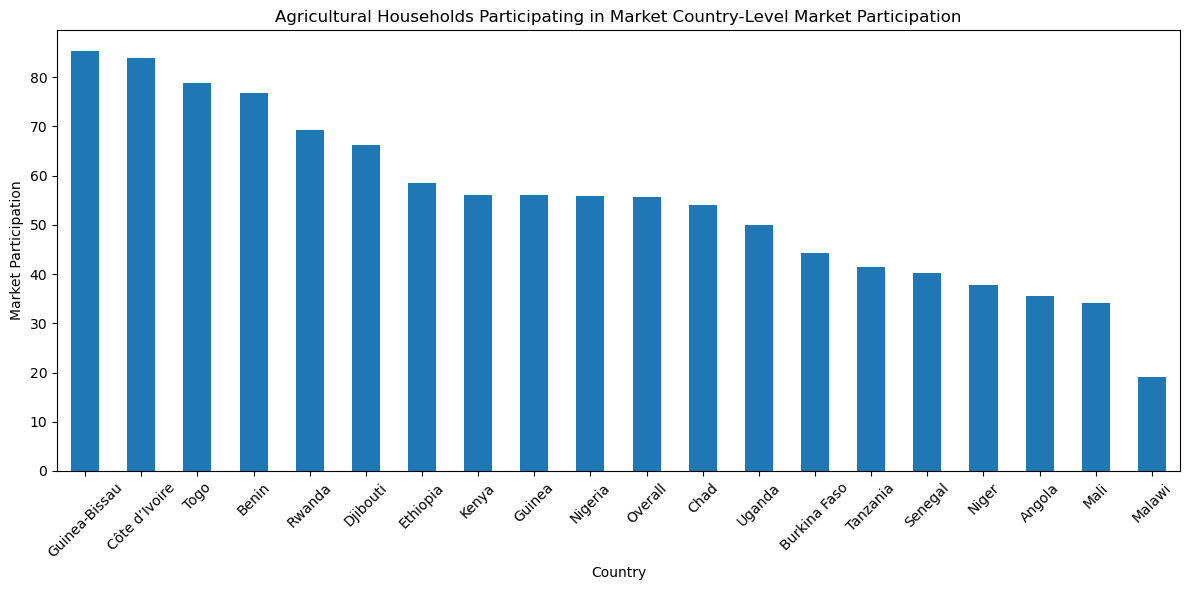

In [21]:
market = df[df["INDICATOR_LABEL"].str.contains(
    "market participation", case=False, na=False
)]

market_country = (
    market.groupby("REF_AREA_LABEL")["OBS_VALUE"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
market_country.plot(kind="bar")

plt.title("Agricultural Households Participating in Market Country-Level Market Participation")
plt.xlabel("Country")
plt.ylabel("Market Participation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart shows differences in market participation across countries. Some countries like Guinea-Bissau and Cote d'Ivoire have considerably higher levels of market participation than others, indicating that participation in agricultural markets varies across countries. The differences suggest that factors such as access to markets, agricultural inputs and economic conditions may influence participation.

## Figure 2: South Africa interest margin to gross income trend (2008-2024)


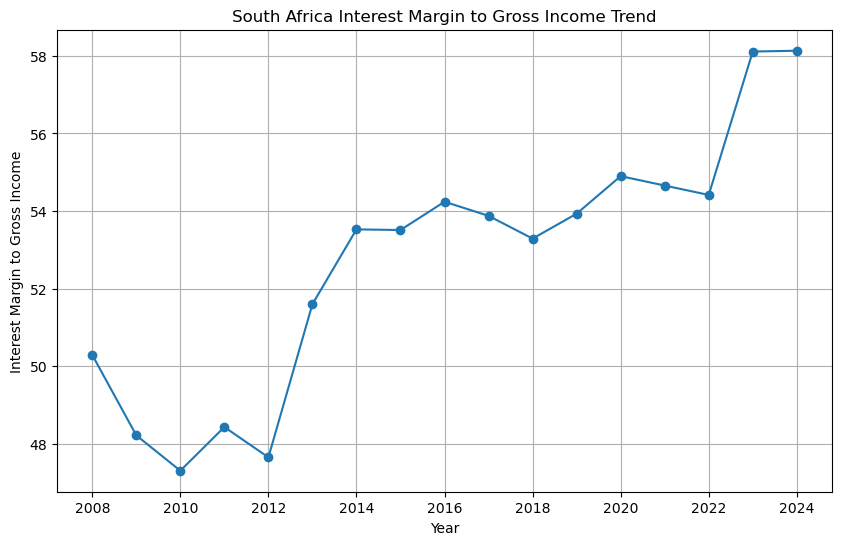

In [9]:
sa_interest = df[
    (df["REF_AREA_LABEL"] == "South Africa") &
    (df["INDICATOR_LABEL"].str.contains(
        "interest margin",
        case=False,
        na=False
    ))
]

sa_interest = sa_interest.sort_values("TIME_PERIOD")

plt.figure(figsize=(10, 6))

plt.plot(
    sa_interest["TIME_PERIOD"],
    sa_interest["OBS_VALUE"],
    marker="o"
)

plt.title("South Africa Interest Margin to Gross Income Trend")
plt.xlabel("Year")
plt.ylabel("Interest Margin to Gross Income")

plt.grid(True)
plt.show()

The graph shows an overall increase in South Africa's interest margin to gross income between 2008 and 2024. There were fluctuations, particularly between 2008 and 2012, but the indicator generally increased after 2013. The largest increase occurred between 2022 and 2023, reaching about 58.1%, where it remained in 2024.

## Figure 3: Fertilizer Adoption vs. Market Participation
Scatter plot assessing the relationship between inorganic fertilizer adoption and market participation, fitted with an ordinary least squares regression line.

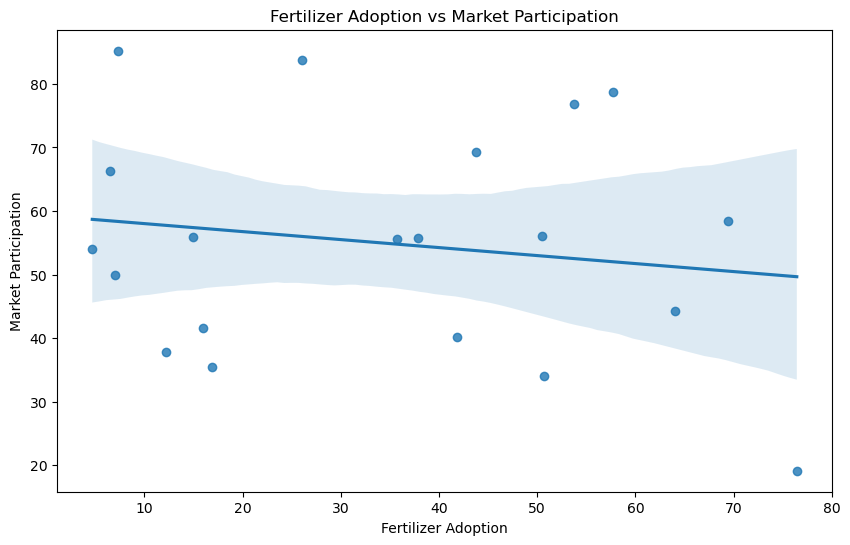

Slope: -0.1258
Intercept: 59.2717
R-squared: 0.0266
Correlation (r): -0.1632
P-value: 0.4919
Standard error: 0.1793

Regression equation: Market Participation = -0.126 * Fertilizer Adoption + 59.272


In [58]:

fertilizer = df[df["INDICATOR_LABEL"].str.contains(
    "fertilizer", case=False, na=False
)][["REF_AREA_LABEL", "TIME_PERIOD", "OBS_VALUE"]]
fertilizer = fertilizer.rename(columns={
    "OBS_VALUE": "Fertilizer Adoption"
})

market = df[df["INDICATOR_LABEL"].str.contains(
    "market participation", case=False, na=False
)][["REF_AREA_LABEL", "TIME_PERIOD", "OBS_VALUE"]]
market = market.rename(columns={
    "OBS_VALUE": "Market Participation"
})

comparison = pd.merge(
    fertilizer,
    market,
    on=["REF_AREA_LABEL", "TIME_PERIOD"],
    how="inner"
)

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.regplot(
    data=comparison,
    x="Fertilizer Adoption",
    y="Market Participation"
)
plt.title("Fertilizer Adoption vs Market Participation")
plt.xlabel("Fertilizer Adoption")
plt.ylabel("Market Participation")
plt.show()

# --- Regression stats behind the line ---
clean = comparison.dropna(subset=["Fertilizer Adoption", "Market Participation"])
x = clean["Fertilizer Adoption"]
y = clean["Market Participation"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"Correlation (r): {r_value:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Standard error: {std_err:.4f}")
print(f"\nRegression equation: Market Participation = {slope:.3f} * Fertilizer Adoption + {intercept:.3f}")


Looking at the data, there doesn't seem to be a strong connection between fertilizer adoption and market participation. While the trend line shows a slight downward pattern meaning areas with more fertilizer use tend to have marginally lower market participation the relationship is very weak and inconsistent. The data points are scattered widely, with market participation varying a lot regardless of fertilizer adoption levels. This suggests that fertilizer adoption alone doesn't really explain or predict market participation; other factors are likely much more important. One unusual data point, where very high fertilizer adoption was paired with very low market participation, may also be skewing the trend line more than it should. Overall, the results suggest little to no meaningful relationship between the two variables in this dataset.

## Figure 4 Input Agricultural Adoption Composition (Pie Chart)
Pie chart highlighting the relative proportion of mean adoption across the three primary inputs: Improved Seeds, Inorganic Fertilizer, and Irrigation.

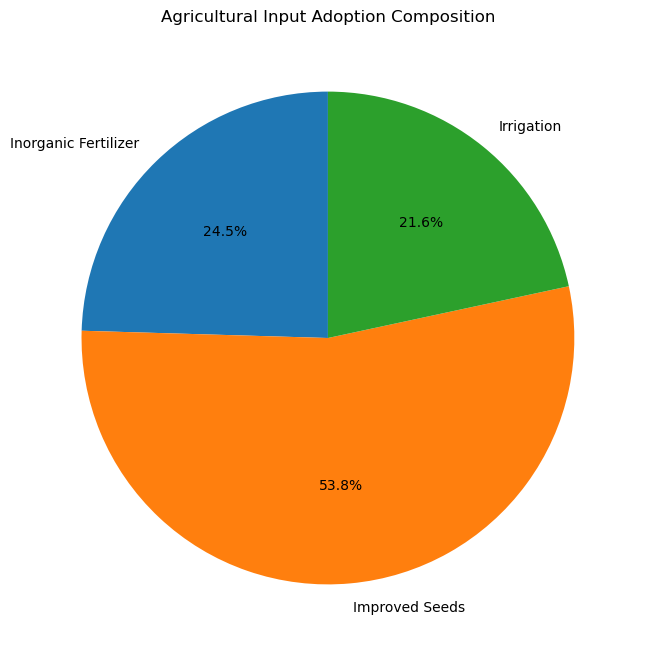

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Select the three agricultural input indicators
inputs = df1[
    df1["INDICATOR_LABEL"].str.contains(
        "inorganic fertilizer|improved seeds|irrigation",
        case=False,
        na=False
    )
].copy()


input_values = (
    inputs.groupby("INDICATOR_LABEL")["OBS_VALUE"]
    .mean()
)

# Short labels
labels = [
    "Inorganic Fertilizer",
    "Improved Seeds",
    "Irrigation"
]


plt.figure(figsize=(8, 8))

plt.pie(
    input_values.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Agricultural Input Adoption Composition")

plt.show()

The pie chart illustrates the relative adoption of three agricultural inputs: inorganic fertilizer, improved seeds and irrigation. The size of each segment shows the relative average adoption level of each input across the countries in the dataset. This makes it easy to identify which agricultural input has the highest and lowest adoption.

The largest slice represents the input with the highest average adoption level in the dataset.improved seeds represent the adoption of improved agricultural technologies

## Figure 5: Median household cultivated land distribution
Histogram illustrating the distribution of median farm plot sizes in hectares across surveyed SSA countries.

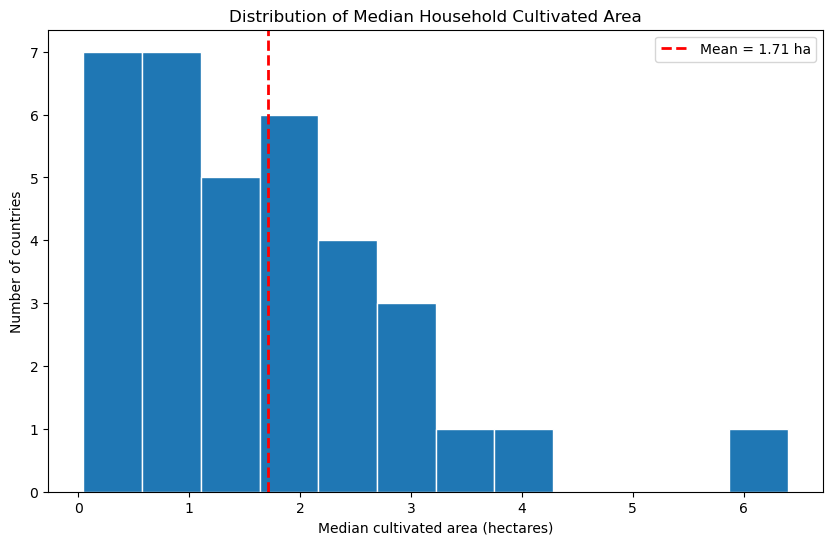

In [56]:
import matplotlib.pyplot as plt

sub = df1[
    df1["INDICATOR_LABEL"] == "Median Agricultural Household Cultivated Area"
]

plt.figure(figsize=(10, 6))

plt.hist(sub["OBS_VALUE"], bins=12, edgecolor="white")

plt.axvline(
    sub["OBS_VALUE"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {sub['OBS_VALUE'].mean():.2f} ha"
)

plt.title("Distribution of Median Household Cultivated Area")
plt.xlabel("Median cultivated area (hectares)")
plt.ylabel("Number of countries")
plt.legend()

plt.show()

The histogram shows how median agricultural household cultivated areas are distributed across the countries. Most countries are concentrated within the lower cultivated-area ranges, while fewer countries have substantially larger cultivated areas. The red dashed line represents the mean cultivated area, allowing the average to be compared with the overall distribution. The graph helps identify whether cultivated areas are relatively similar across countries or whether there are large differences between them.

# 4. Data Integration

## **Step 1: Import sqlite3 and connect to a database**

In [62]:
import sqlite3
import pandas as pd

def create_connection(db_name="worldbank_data.db"):
    """Create a database connection with error handling."""
    try:
        conn = sqlite3.connect(db_name)
        print(f"Connected to {db_name} successfully.")
        return conn
    except sqlite3.Error as e:
        print(f"Error connecting to database: {e}")
        return None

conn = create_connection()

Connected to worldbank_data.db successfully.


## **Step 2: Create your tables**

In [63]:

          def create_tables(conn):
    """Create tables matching our two actual datasets."""
    try:
        cursor = conn.cursor()

        # Table 1: Interest Margin to Gross Income (ZAF time series)
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS interest_margin (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                country TEXT NOT NULL,
                year INTEGER NOT NULL,
                quarter INTEGER,
                interest_margin_value REAL
            )
        """)

        # Table 2: Agri-Connect Indicators (long format - many indicator codes)
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS agri_indicators (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                country TEXT NOT NULL,
                indicator_code TEXT NOT NULL,
                indicator_name TEXT,
                year INTEGER NOT NULL,
                value REAL
            )
        """)

        conn.commit()
        print("Both tables created successfully.")
    except sqlite3.Error as e:
        print(f"Error creating tables: {e}")

create_tables(conn)

Both tables created successfully.


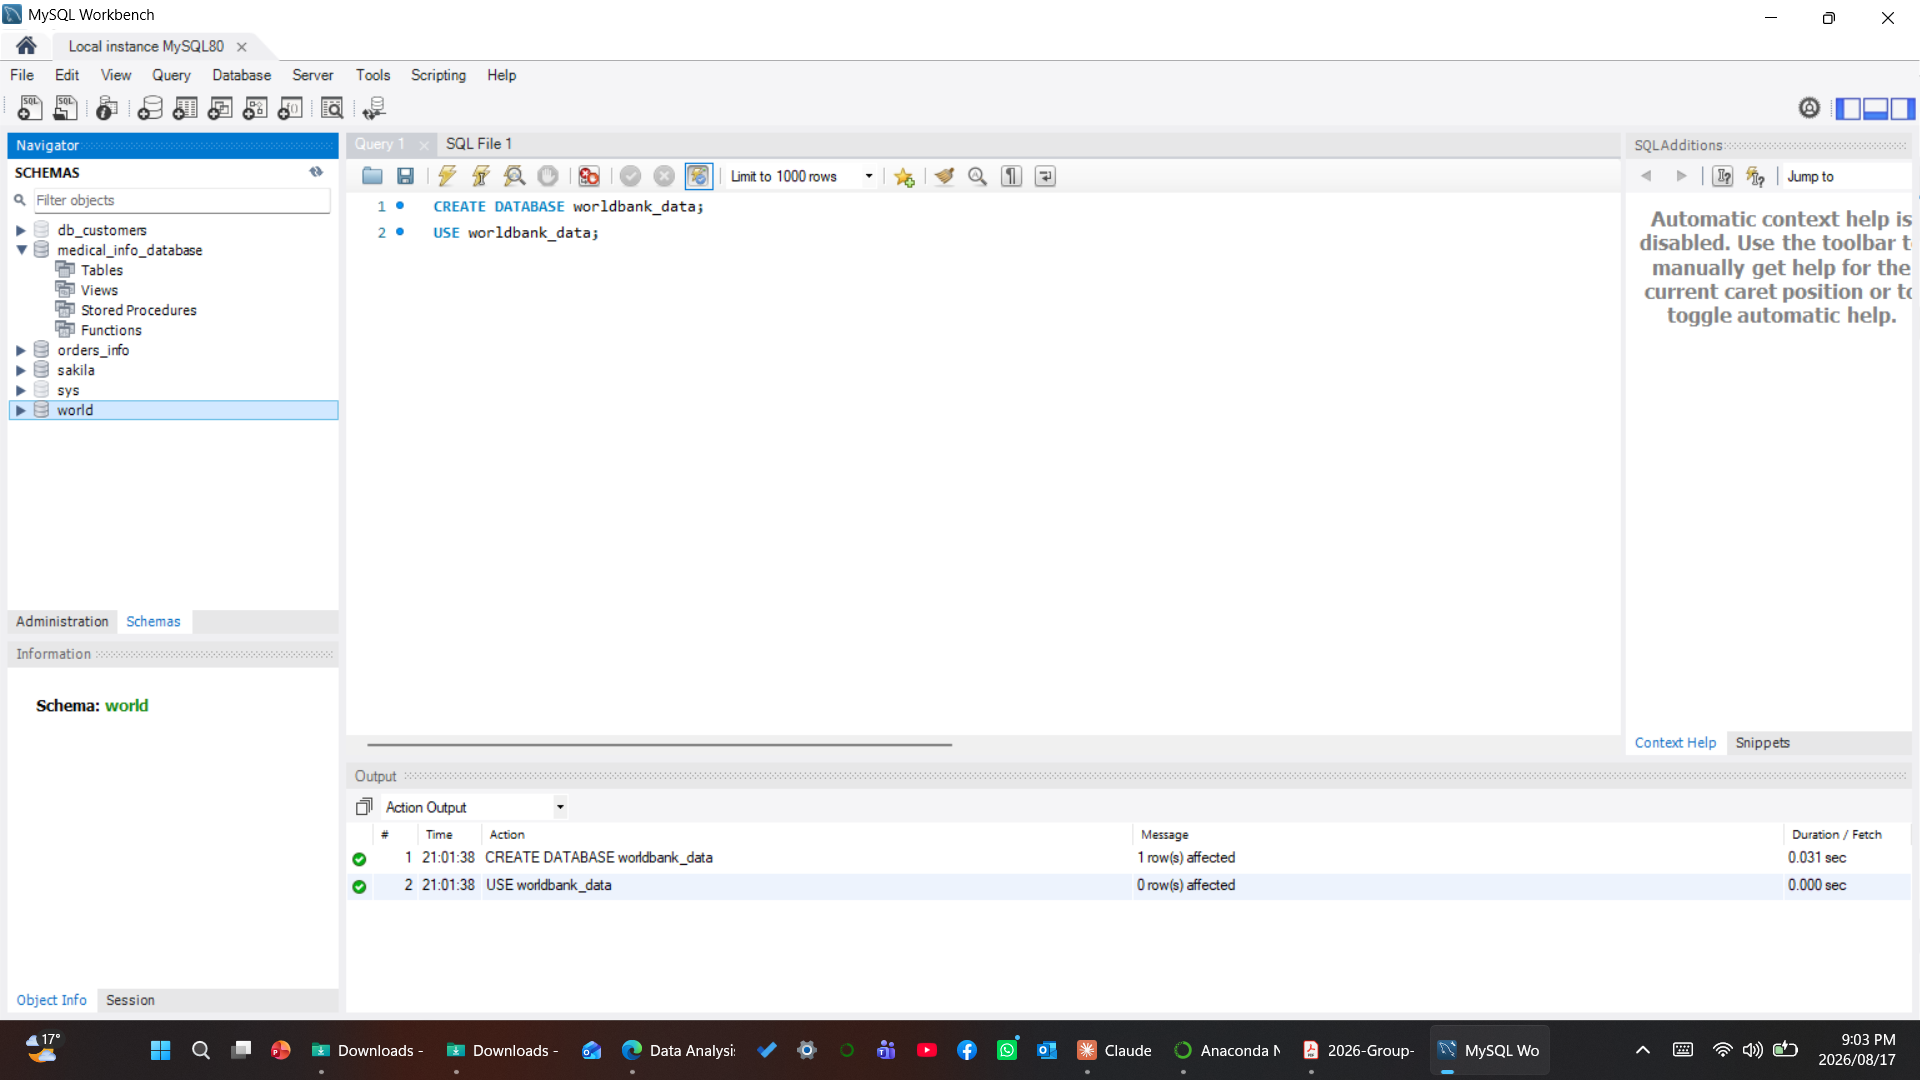

In [64]:
from IPython.display import Image
Image(filename="Screenshot (4).png", width=1000)


**Figure 4.1 — Successful creation of the worldbank_data database in MySQL Workbench.**

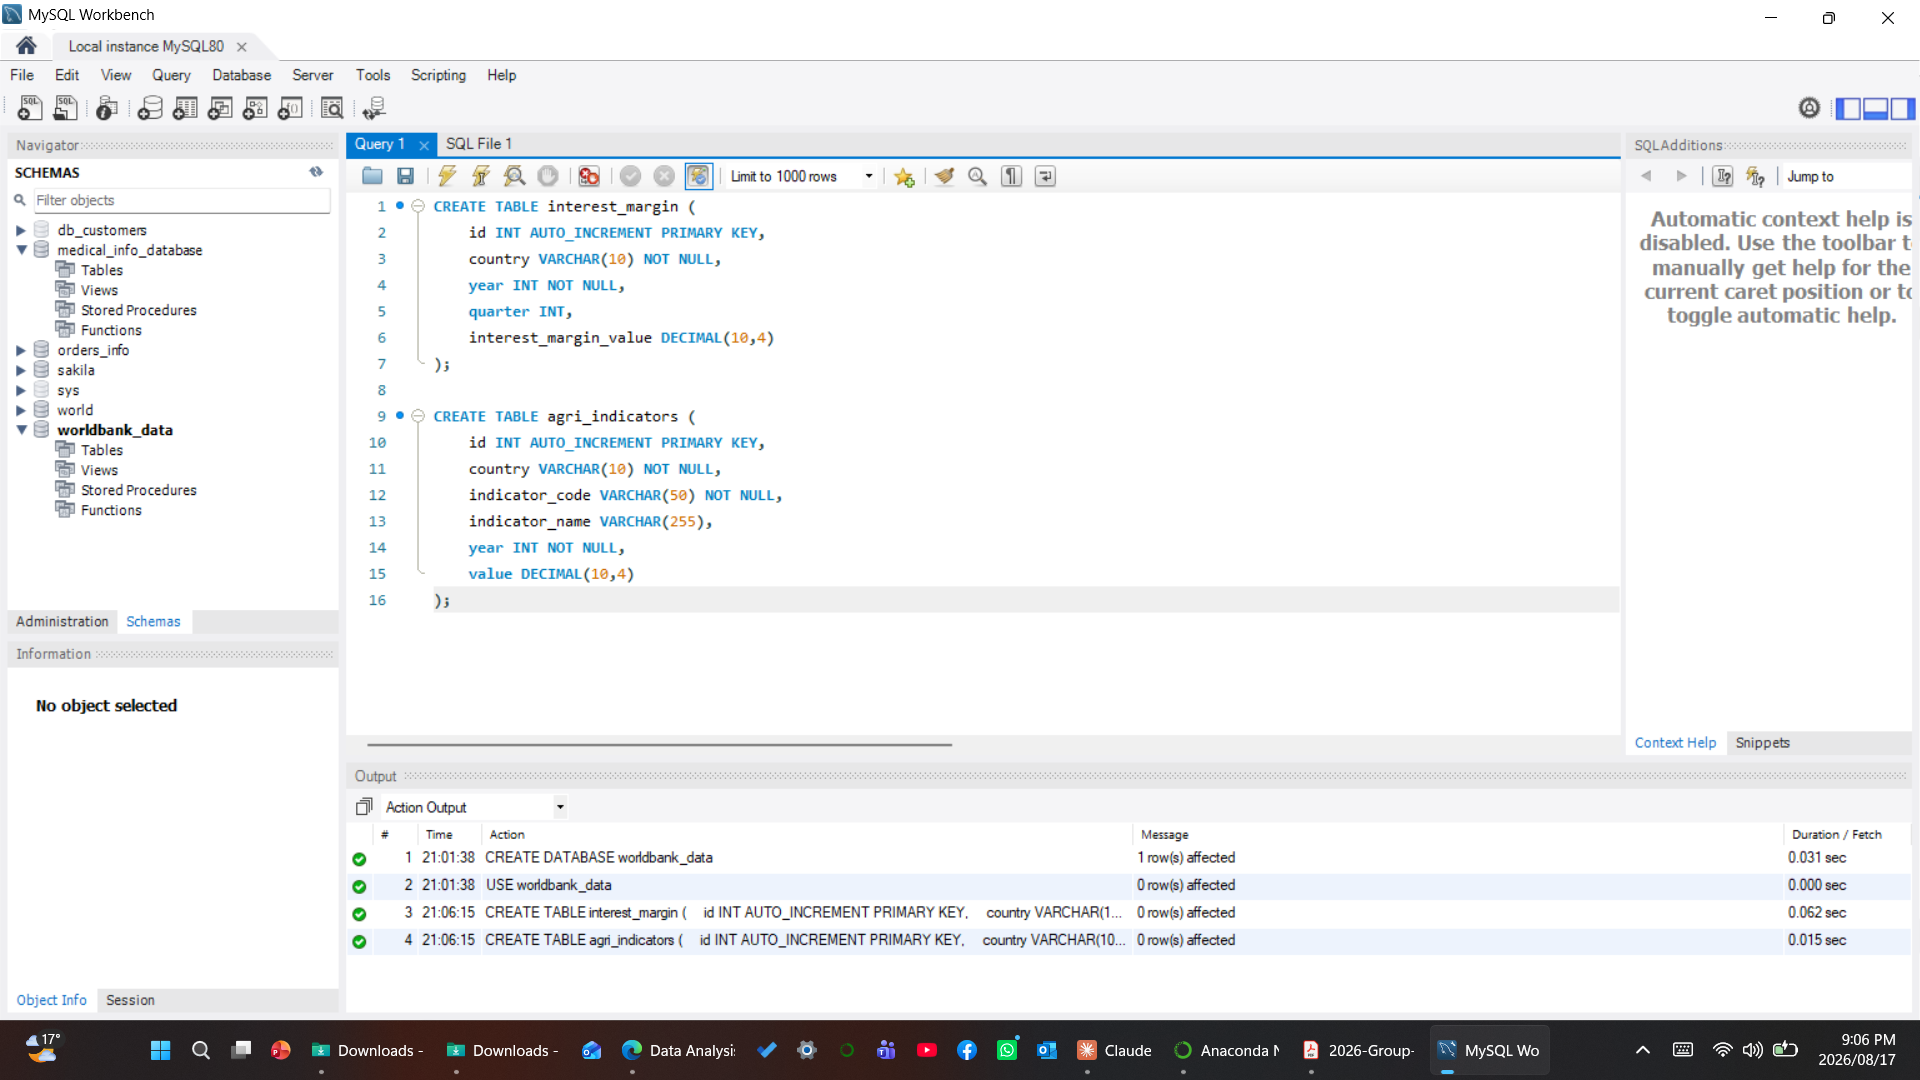

In [65]:
from IPython.display import Image
Image(filename="Screenshot (6).png", width=1000)

**Figure 4.2 — interest_margin and agri_indicators tables created successfully, shown expanded in the schema navigator.**

## **Step 3: Prepare your Interest Margin data to match the interest_margin table**

In [66]:
# --- Prepare Interest Margin data for the database ---
income_for_db = income_clean[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']].copy()
income_for_db['country'] = income_for_db['REF_AREA']
income_for_db['year'] = income_for_db['TIME_PERIOD'].astype(str).str.slice(0, 4).astype(int)
income_for_db['quarter'] = income_for_db['TIME_PERIOD'].astype(str).str.extract(r'Q(\d)').astype('Int64')  # NaN for annual rows
income_for_db['interest_margin_value'] = income_for_db['OBS_VALUE']

income_for_db = income_for_db[['country', 'year', 'quarter', 'interest_margin_value']]
income_for_db = income_for_db.dropna(subset=['interest_margin_value'])  # drop rows with no value

print("Rows ready to load:", len(income_for_db))
income_for_db.head()

Rows ready to load: 15737


,country,year,quarter,interest_margin_value
0,MUS,2009,<NA>,69.051442
1,MUS,2010,<NA>,66.750153
2,MUS,2011,<NA>,65.101696
3,MUS,2012,<NA>,65.710860
4,MUS,2013,<NA>,69.549851


## **Step 4:Prepare your Agri-Connect data to match the agri_indicators table**

In [67]:
# --- Prepare Agri-Connect data for the database ---
agri_for_db = agri[['REF_AREA', 'INDICATOR', 'INDICATOR_LABEL', 'TIME_PERIOD', 'OBS_VALUE']].copy()
agri_for_db.columns = ['country', 'indicator_code', 'indicator_name', 'year', 'value']
agri_for_db['year'] = agri_for_db['year'].astype(int)
agri_for_db = agri_for_db.dropna(subset=['value'])  # drop rows with no value

print("Rows ready to load:", len(agri_for_db))
agri_for_db.head()

Rows ready to load: 157


,country,indicator_code,indicator_name,year,value
0,KEN,AG_SD_HH_PD,Average Sold Percentage of Household Agricultu...,2016,30.695026
1,MLI,AG_SD_HH_PD,Average Sold Percentage of Household Agricultu...,2022,81.868594
2,NER,AG_SD_HH_PD,Average Sold Percentage of Household Agricultu...,2014,9.743613
3,SEN,AG_SD_HH_PD,Average Sold Percentage of Household Agricultu...,2022,34.313242
4,TGO,AG_SD_HH_PD,Average Sold Percentage of Household Agricultu...,2022,46.684265


## **Step 5:Load both prepared DataFrames into the database**

In [68]:
def load_dataframe_to_db(conn, df, table_name):
    """Load a cleaned DataFrame into the database table."""
    try:
        df.to_sql(table_name, conn, if_exists="append", index=False)
        print(f"Loaded {len(df)} rows into '{table_name}'.")
    except Exception as e:
        print(f"Error loading data into database: {e}")

load_dataframe_to_db(conn, income_for_db, "interest_margin")
load_dataframe_to_db(conn, agri_for_db, "agri_indicators")

Loaded 15737 rows into 'interest_margin'.
Loaded 157 rows into 'agri_indicators'.


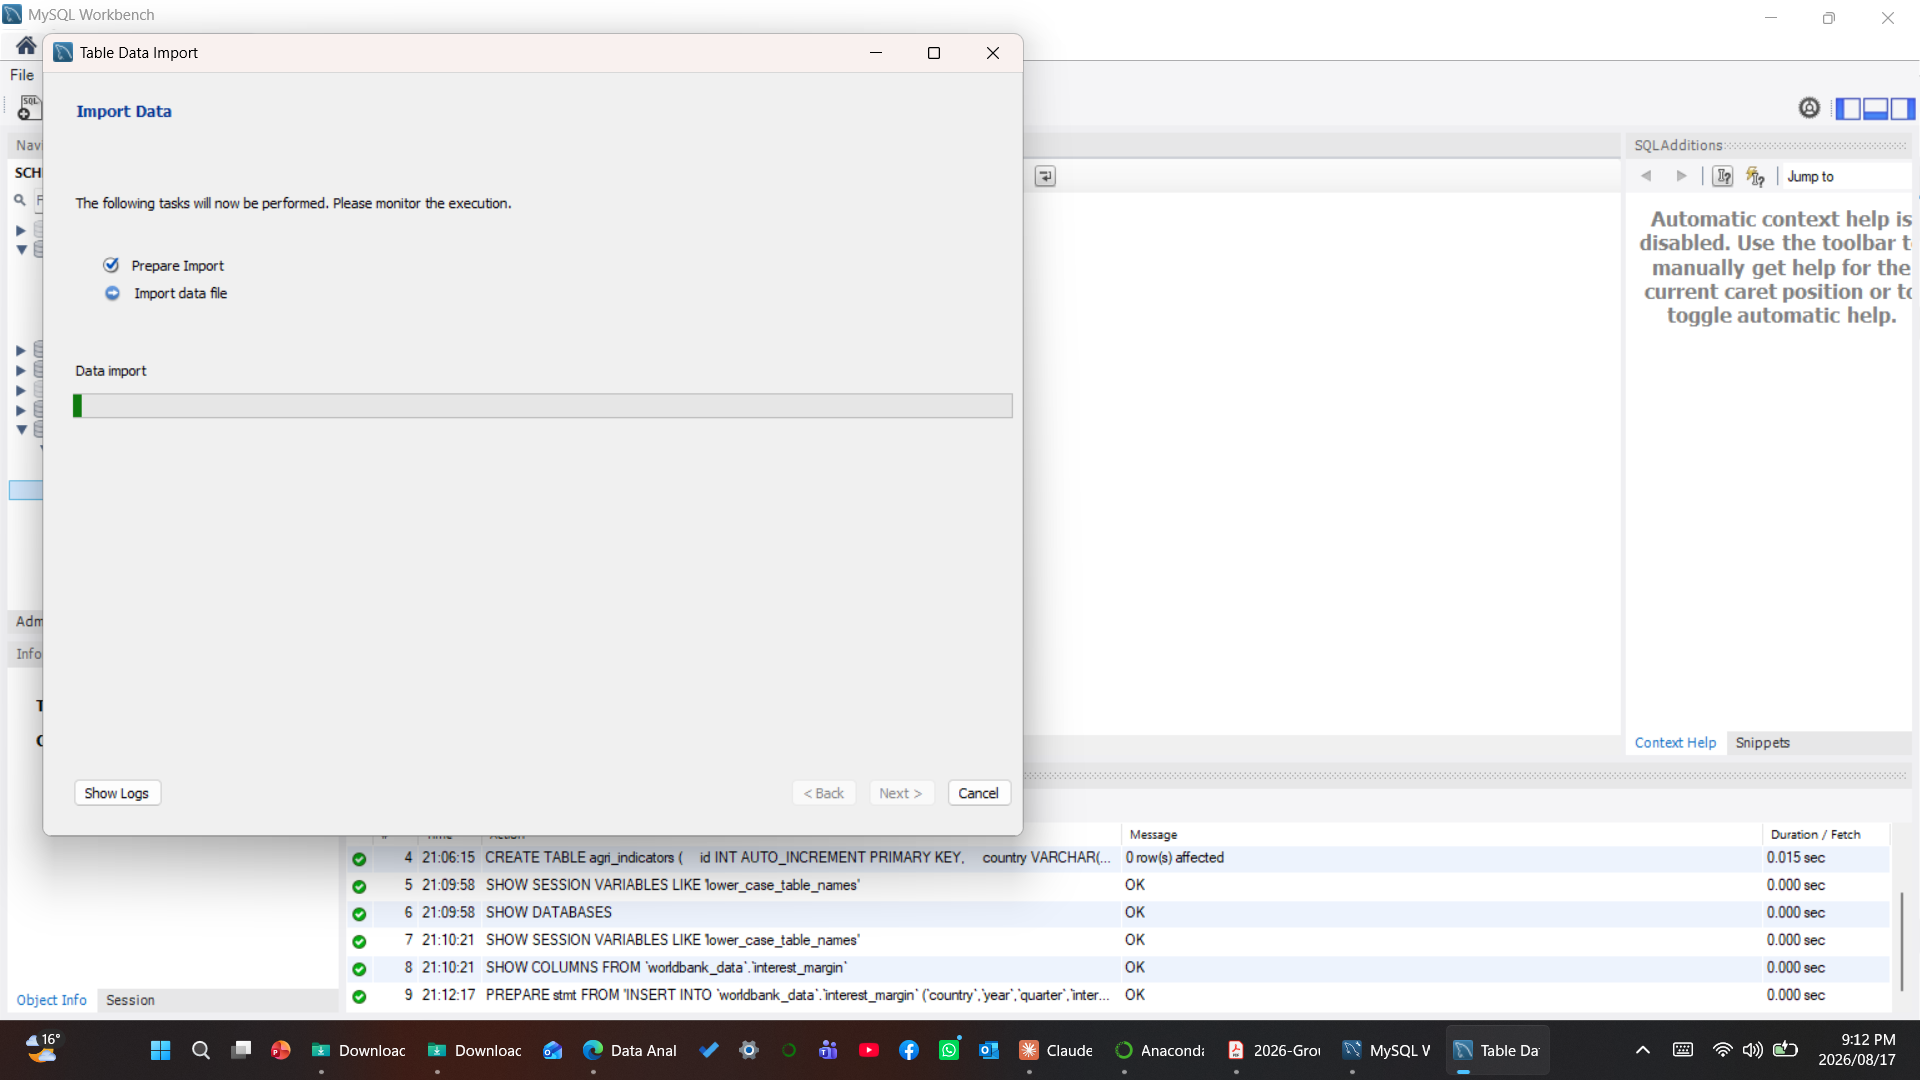

In [69]:
from IPython.display import Image
Image(filename="Screenshot (9).png", width=1000)

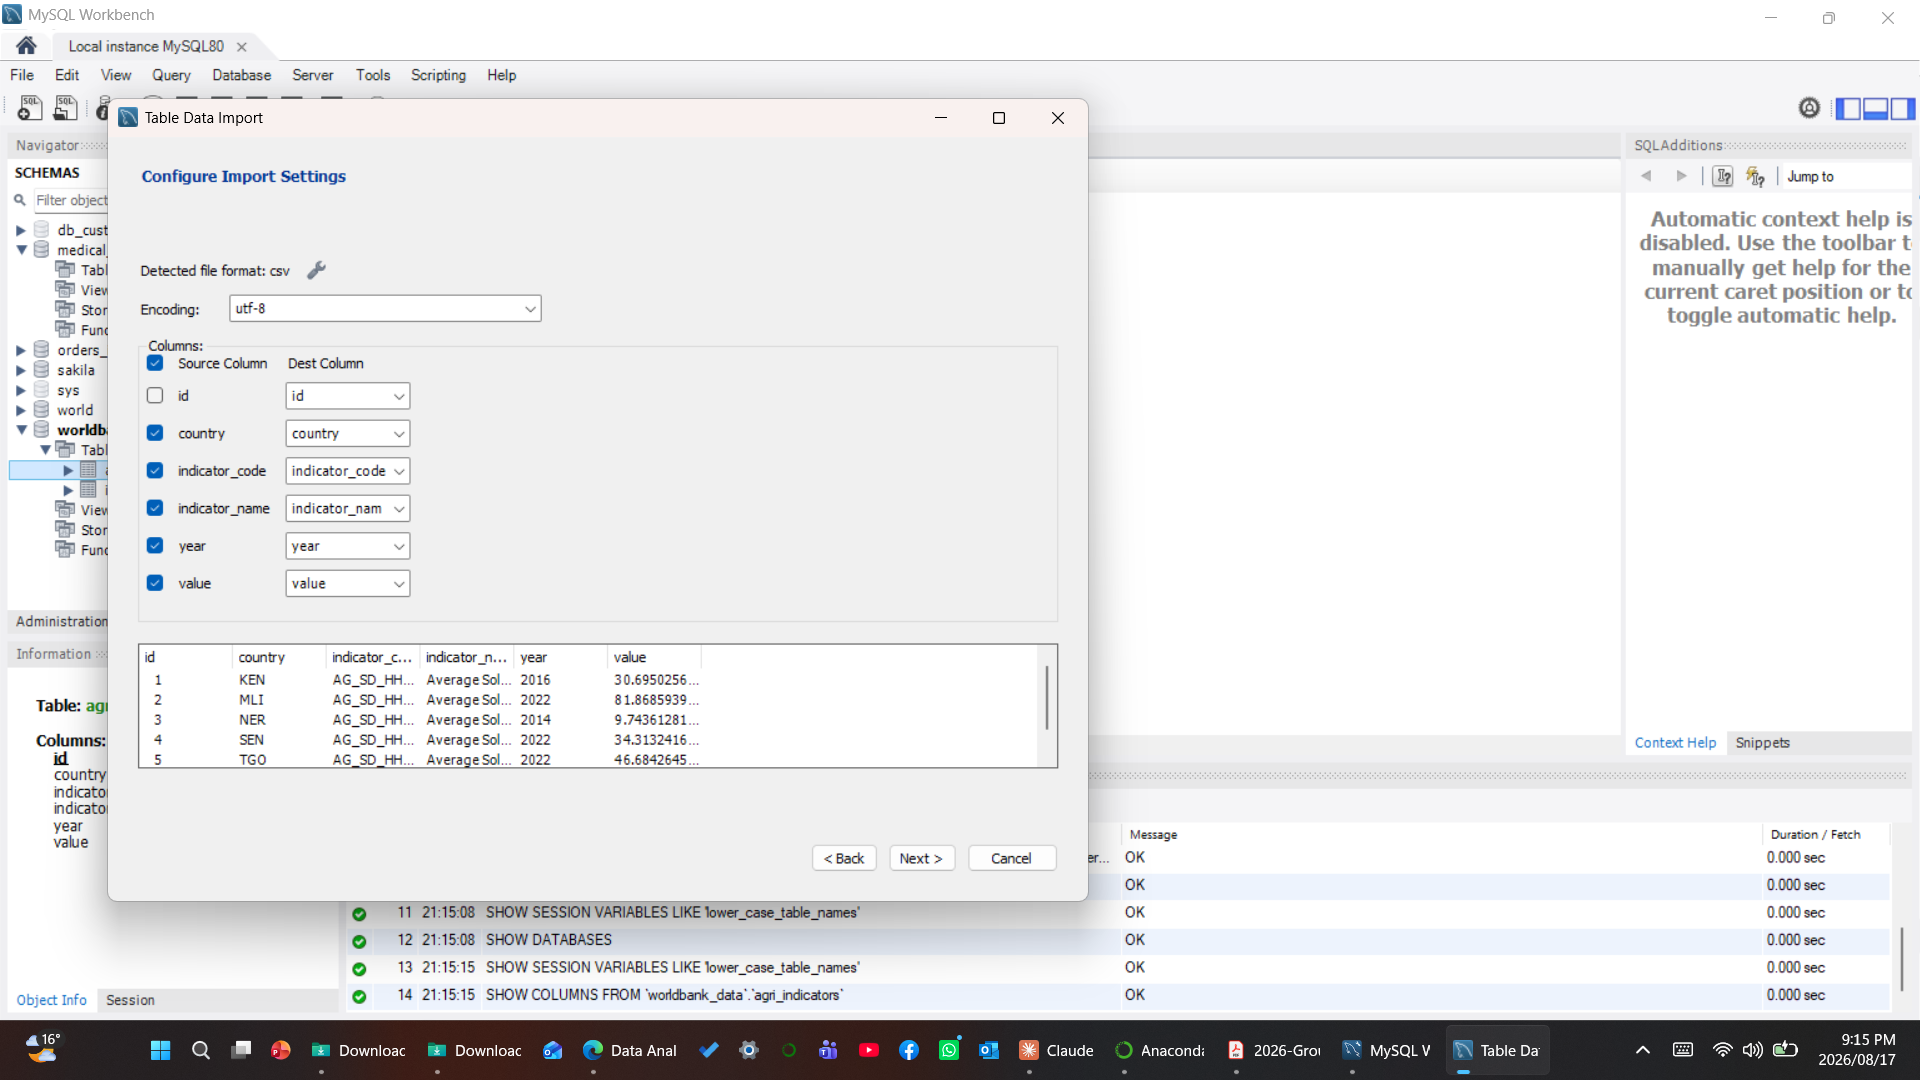

In [70]:
from IPython.display import Image
Image(filename="Screenshot (13).png", width=1000)

**Figure 4.3 — Column mapping step of the Table Data Import Wizard for agri_indicators, aligning CSV columns (country, indicator_code, indicator_name, year, value) with the table schema.**

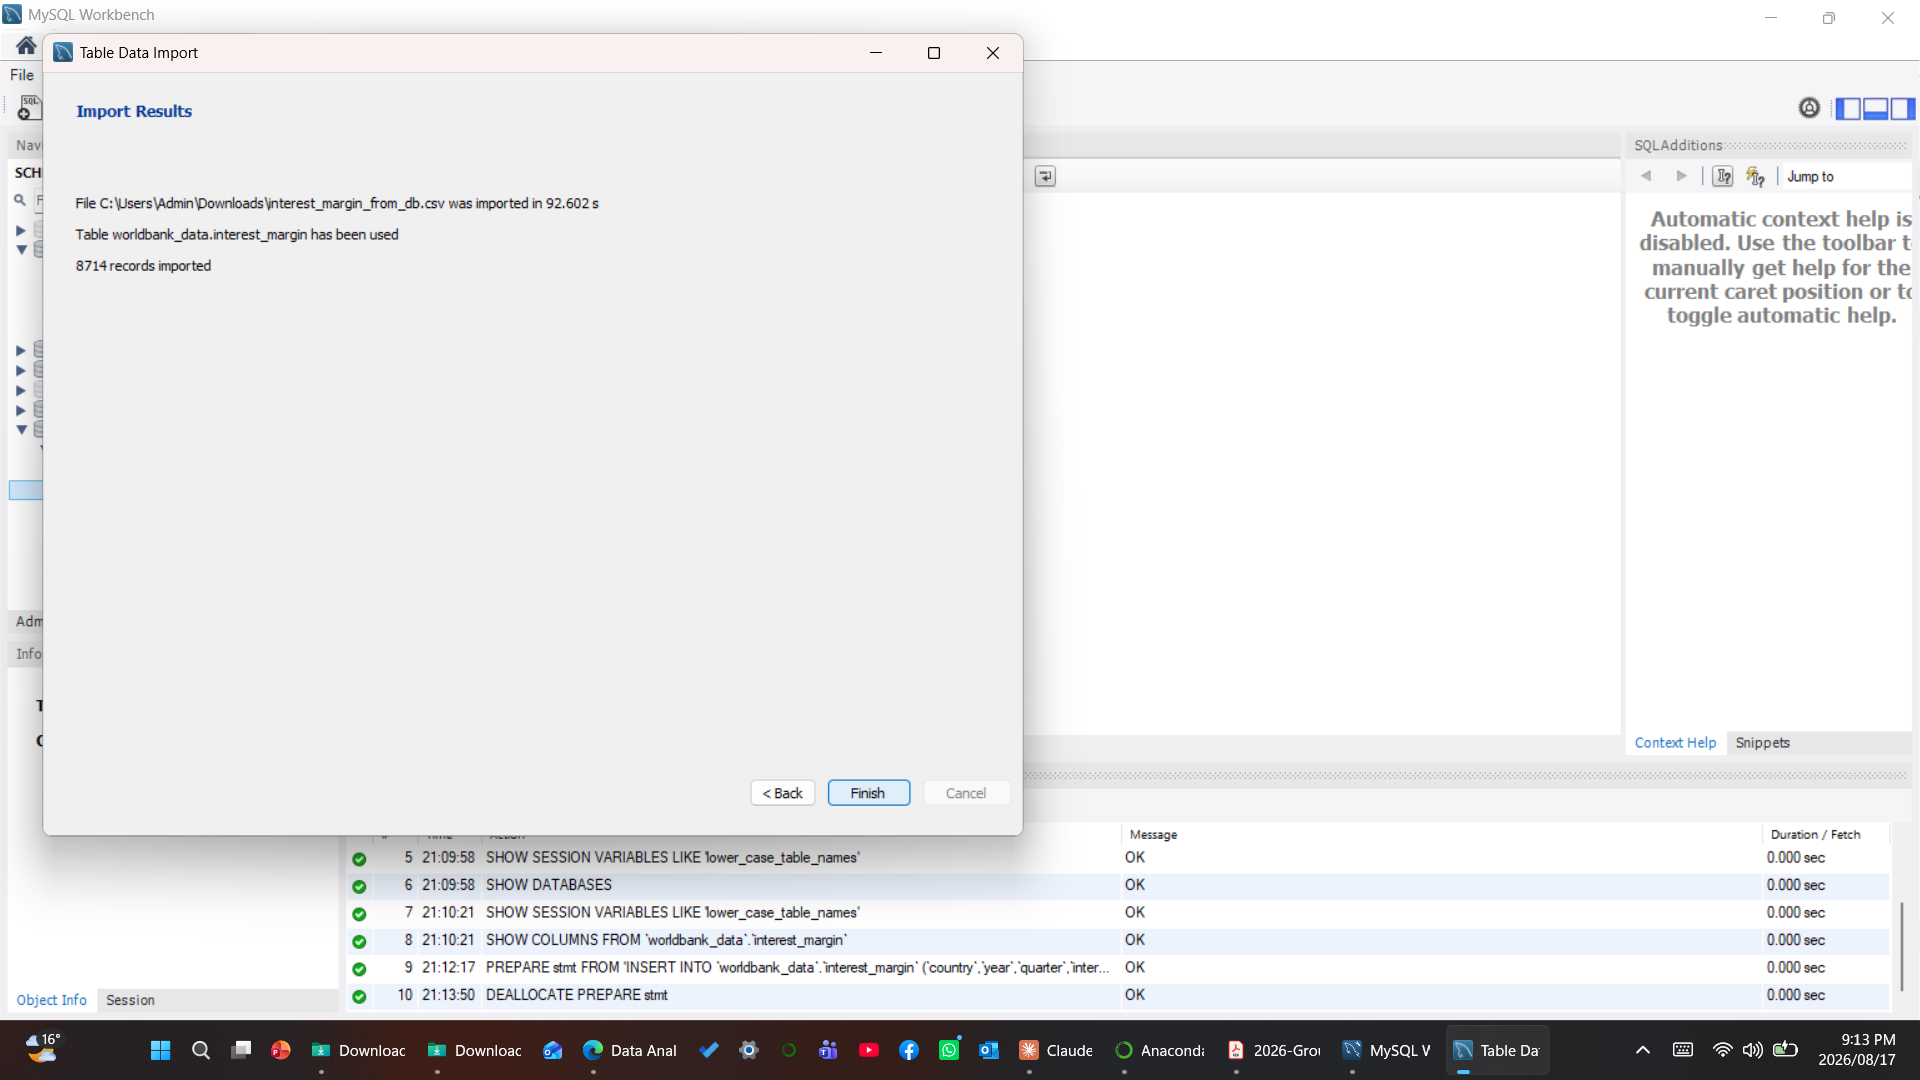

In [71]:
from IPython.display import Image
Image(filename="Screenshot (11).png", width=1000)

**Figure 4.4 — Import confirmation showing 8,714 records successfully imported into interest_margin from interest_margin_from_db.csv.**

**After both imports completed, row counts were verified directly in the database using COUNT(*) queries:
SELECT COUNT(*) FROM interest_margin;    -- 8714
SELECT COUNT(*) FROM agri_indicators;    -- 157**


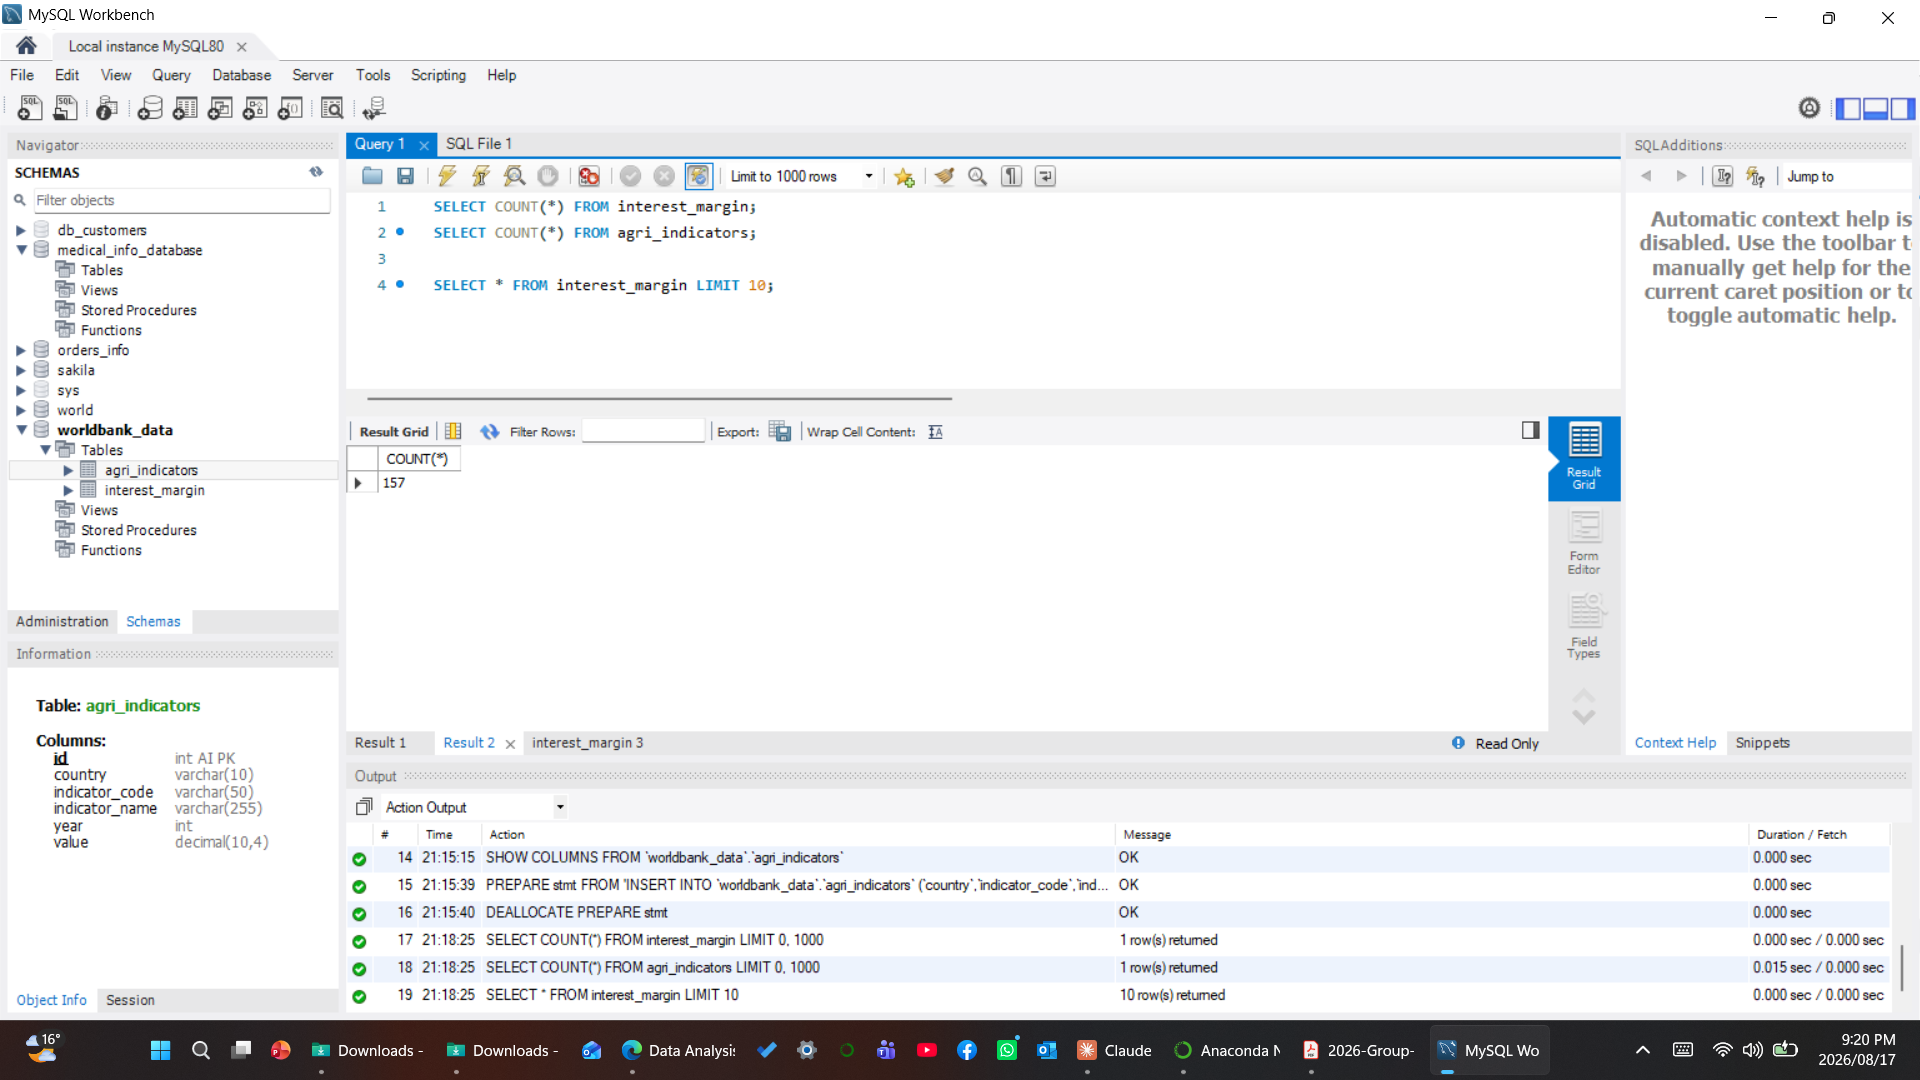

In [72]:
from IPython.display import Image
Image(filename="Screenshot (17).png", width=1000)

 
**Figure 4.5 — Row count verification: 8,714 records in interest_margin, matching the size of the cleaned Interest Margin dataset from Section 1.**


 ## **Step 6:Query the data (SELECT)**

In [73]:
def query_data(conn, query, params=()):
    """Run a SELECT query safely with error handling."""
    try:
        cursor = conn.cursor()
        cursor.execute(query, params)
        return cursor.fetchall()
    except sqlite3.Error as e:
        print(f"Error running query: {e}")
        return []

# Example 1: South Africa's interest margin records
results = query_data(
    conn,
    "SELECT country, year, quarter, interest_margin_value FROM interest_margin WHERE country = ? LIMIT 10",
    ("ZAF",)
)
print("--- Interest Margin (ZAF) ---")
for row in results:
    print(row)

--- Interest Margin (ZAF) ---
('ZAF', 2008, None, 50.28901398775975)
('ZAF', 2009, None, 48.21487818890926)
('ZAF', 2010, None, 47.3024025736644)
('ZAF', 2011, None, 48.42928416520439)
('ZAF', 2012, None, 47.64757824861825)
('ZAF', 2013, None, 51.59803518039978)
('ZAF', 2014, None, 53.52624229224879)
('ZAF', 2015, None, 53.51000498730026)
('ZAF', 2016, None, 54.23905736634543)
('ZAF', 2017, None, 53.87539818125979)


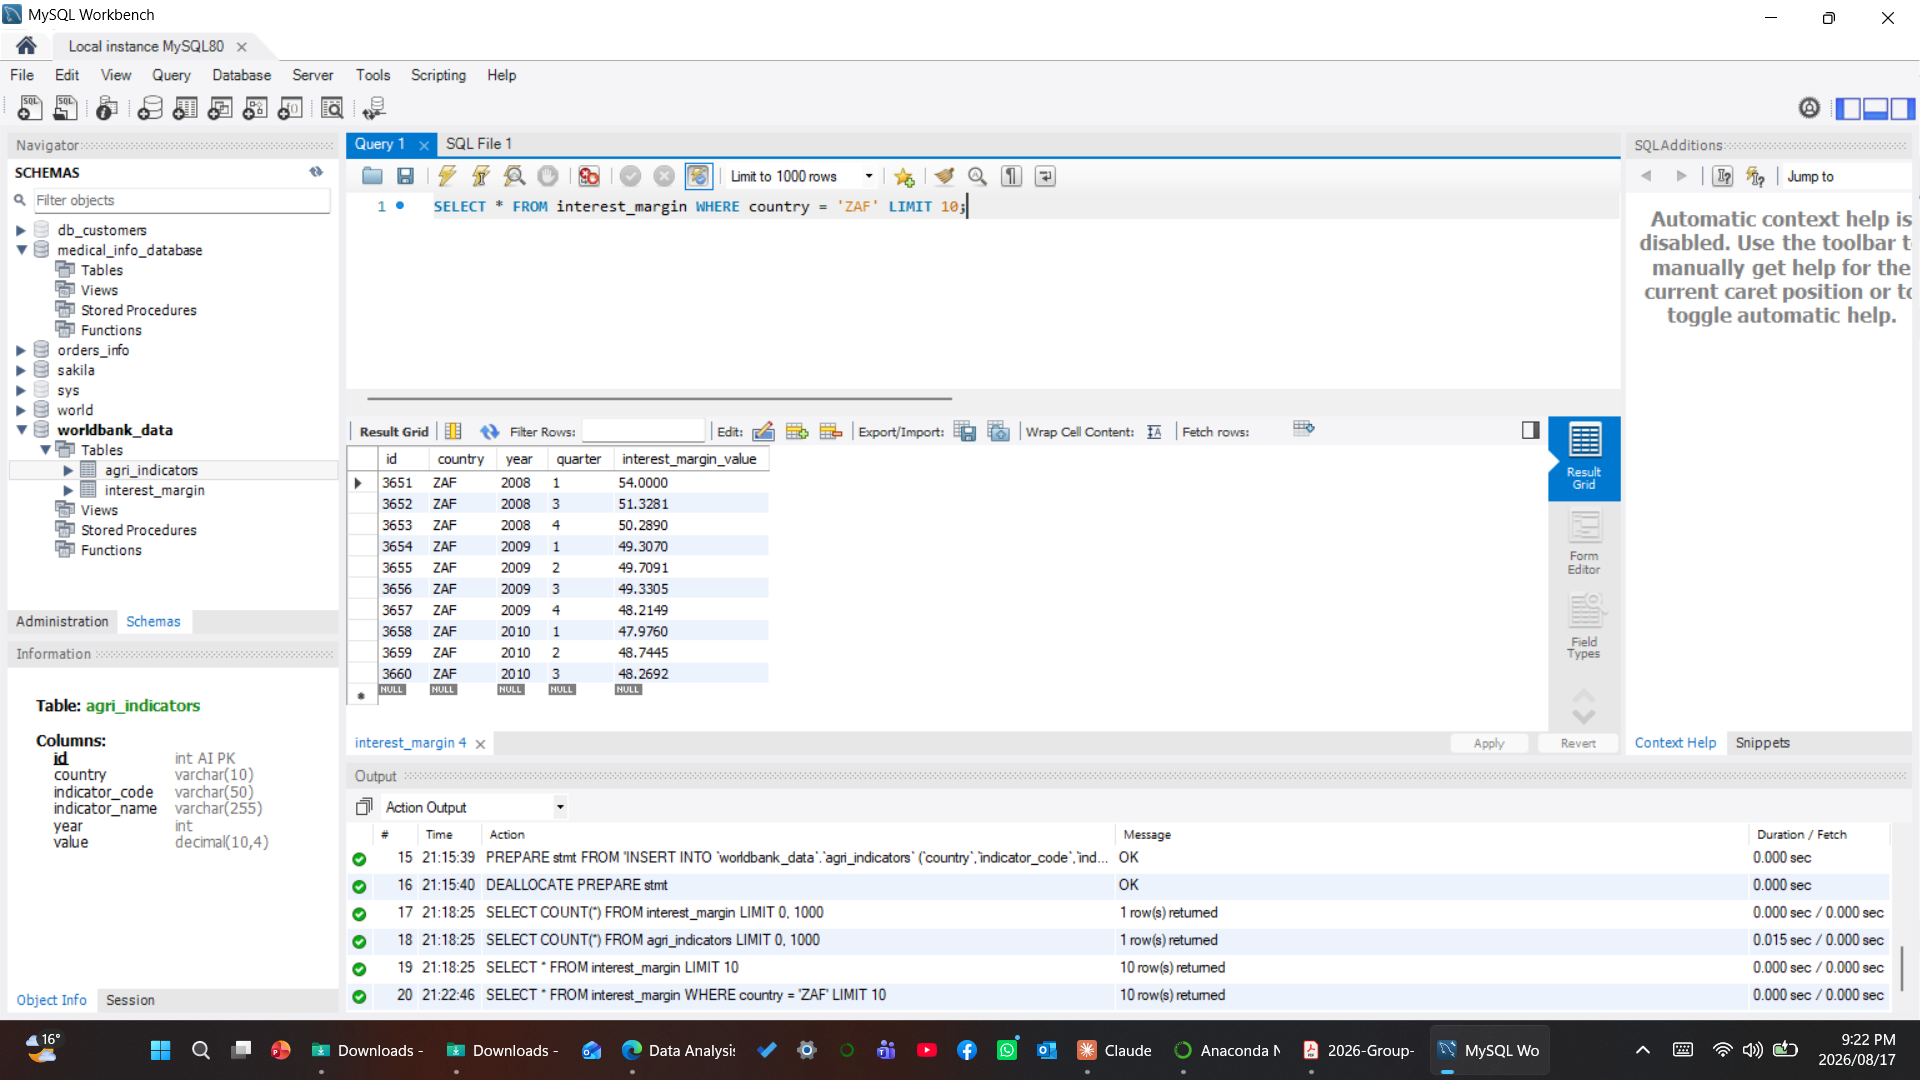

In [74]:
from IPython.display import Image
Image(filename="Screenshot (19).png", width=1000)

**Figure 4.6 — Query results showing South Africa's interest margin values by year and quarter, retrieved directly from the database**

## **Step 7: Update a record safely**

In [75]:
def update_record(conn, year, quarter, new_value, country="ZAF"):
    """Update a record safely using a parameterized query."""
    try:
        cursor = conn.cursor()
        cursor.execute("""
            UPDATE interest_margin
            SET interest_margin_value = ?
            WHERE country = ? AND year = ? AND quarter = ?
        """, (new_value, country, year, quarter))
        conn.commit()
        print(f"Updated {cursor.rowcount} row(s).")
    except sqlite3.Error as e:
        print(f"Error updating record: {e}")

**Before you update — run a quick SELECT to see the current value first**

In [76]:
before = query_data(
    conn,
    "SELECT country, year, quarter, interest_margin_value FROM interest_margin WHERE country=? AND year=? AND quarter=?",
    ("ZAF", 2008, 1)
)
print("Before update:", before)

Before update: [('ZAF', 2008, 1, 54.0), ('ZAF', 2008, 1, 53.69315503480354), ('ZAF', 2008, 1, 53.69315503480354)]


**Now run the update**

In [77]:
update_record(conn, year=2008, quarter=1, new_value=54.0)

Updated 3 row(s).


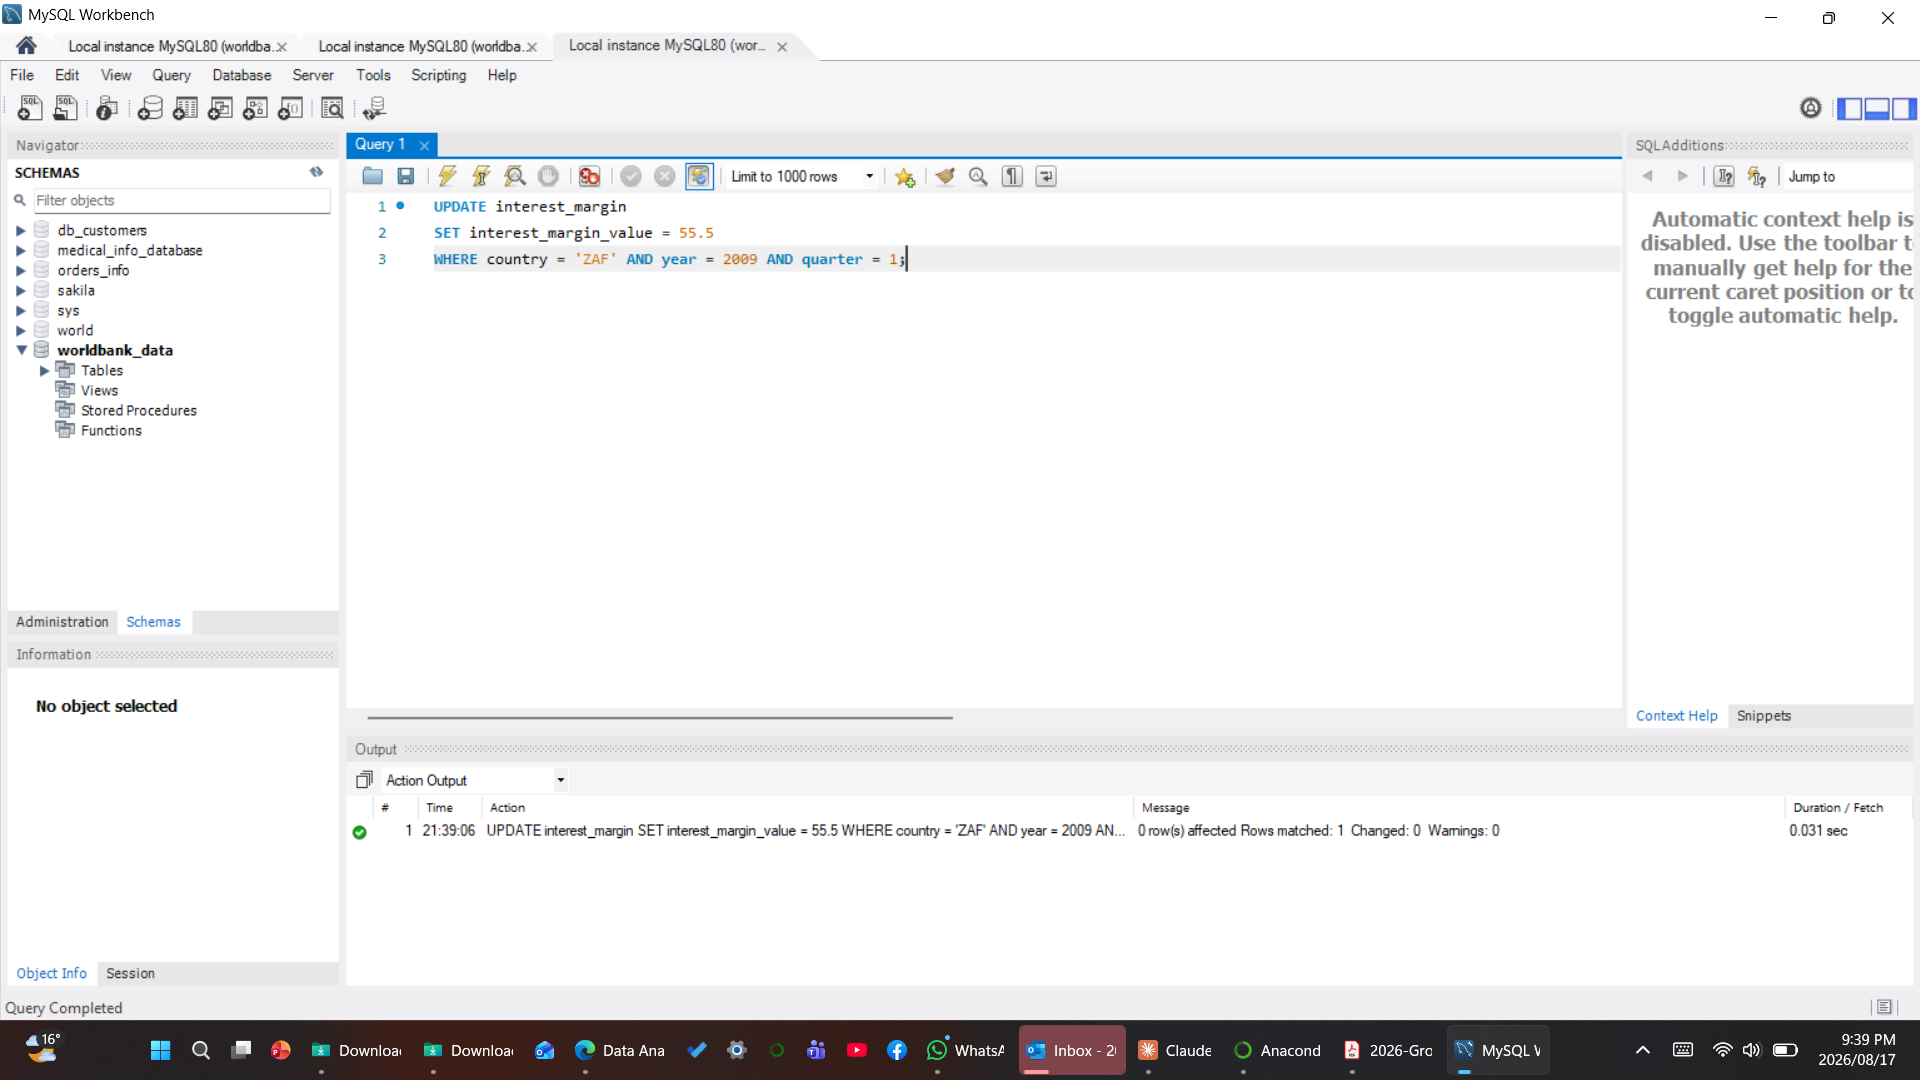

In [78]:
from IPython.display import Image
Image(filename="Screenshot (22).png", width=1000)

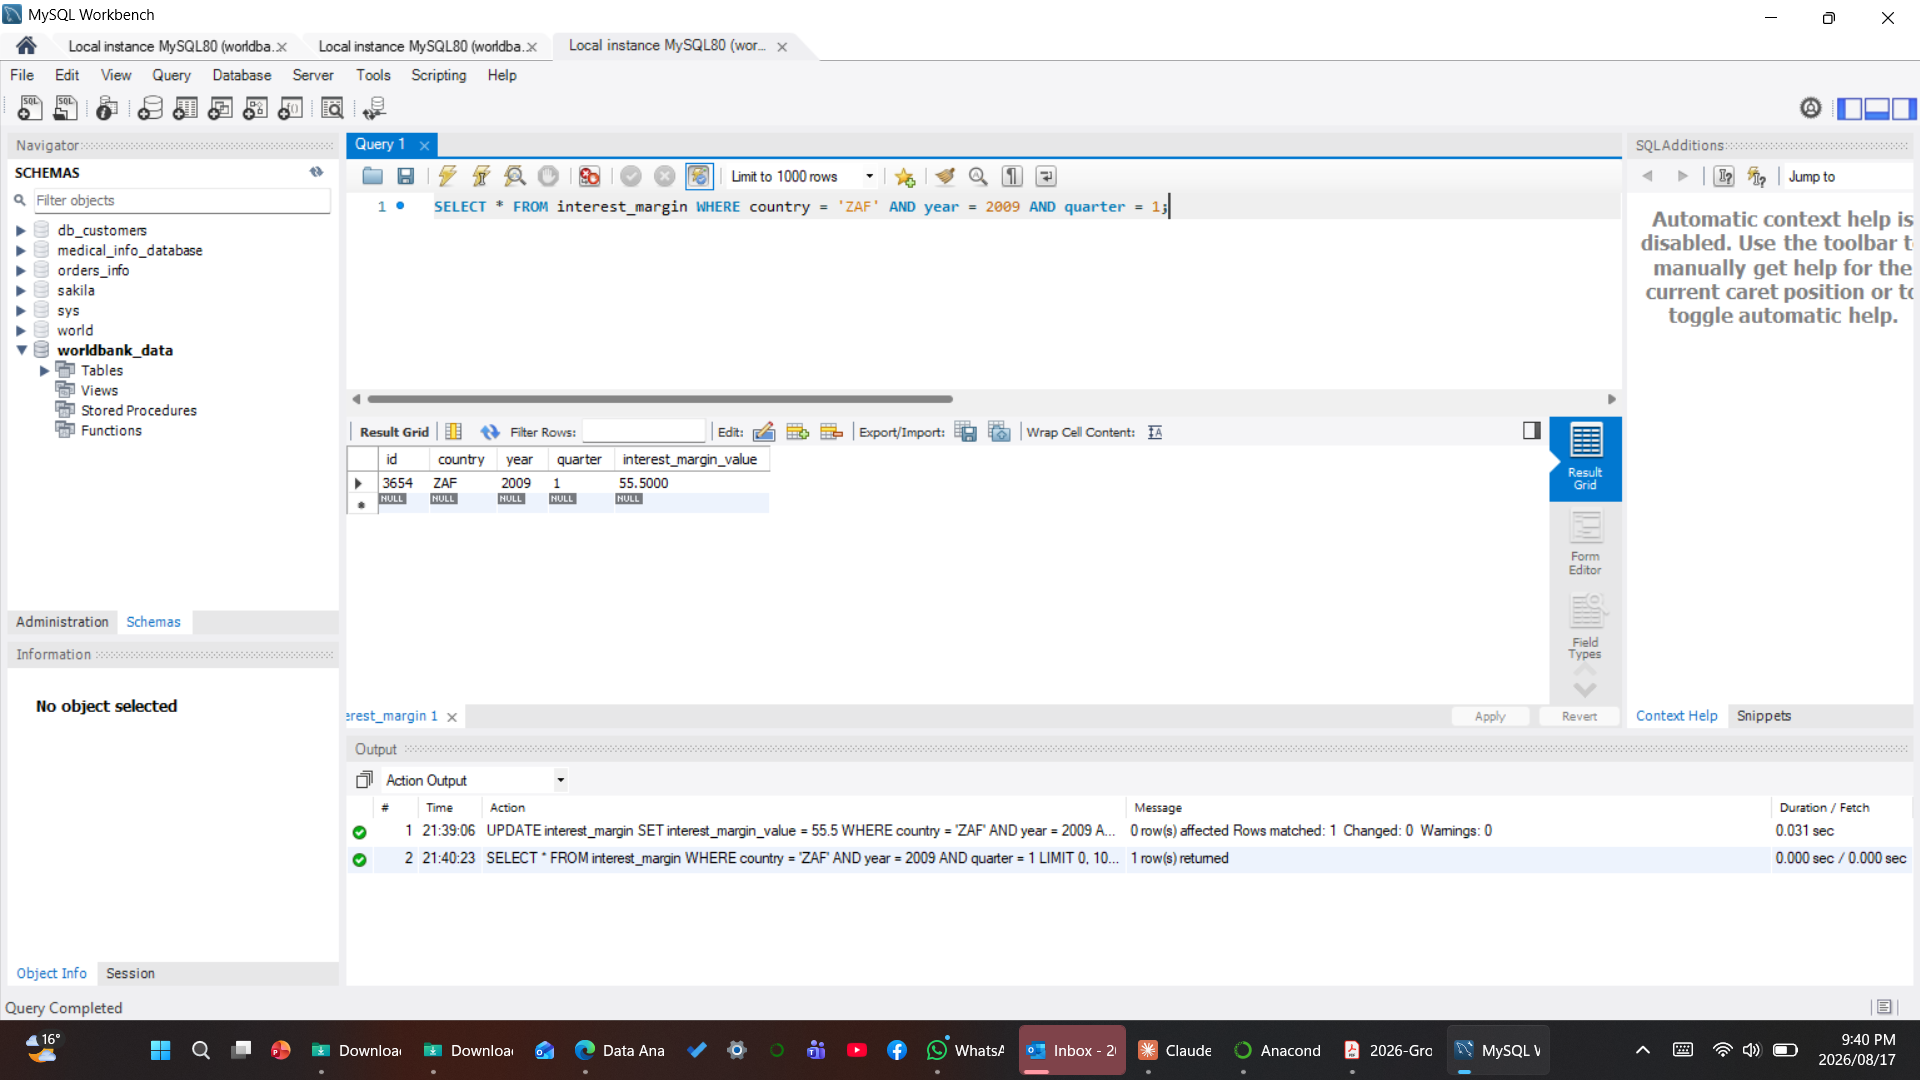

In [79]:
from IPython.display import Image
Image(filename="Screenshot (23).png", width=1000)

**Figure 4.7 — Verification query confirming the updated interest_margin_value (55.5000) for South Africa, 2009 quarter 1**


## **Step 8: Delete a record safely**

In [80]:
def delete_record(conn, country, year, quarter=None):
    """Delete a record safely using a parameterized query."""
    try:
        cursor = conn.cursor()
        if quarter is not None:
            cursor.execute("DELETE FROM interest_margin WHERE country=? AND year=? AND quarter=?",
                            (country, year, quarter))
        else:
            cursor.execute("DELETE FROM interest_margin WHERE country=? AND year=?", (country, year))
        conn.commit()
        print(f"Deleted {cursor.rowcount} row(s).")
    except sqlite3.Error as e:
        print(f"Error deleting record: {e}")


**Check before deleting:**

In [81]:
before_del = query_data(
    conn,
    "SELECT * FROM interest_margin WHERE country=? AND year=? AND quarter=?",
    ("ZAF", 2008, 2)
)
print("Before delete:", before_del)

Before delete: [(22126, 'ZAF', 2008, 2, 50.96980786837368), (37863, 'ZAF', 2008, 2, 50.96980786837368)]



**Delete it:**



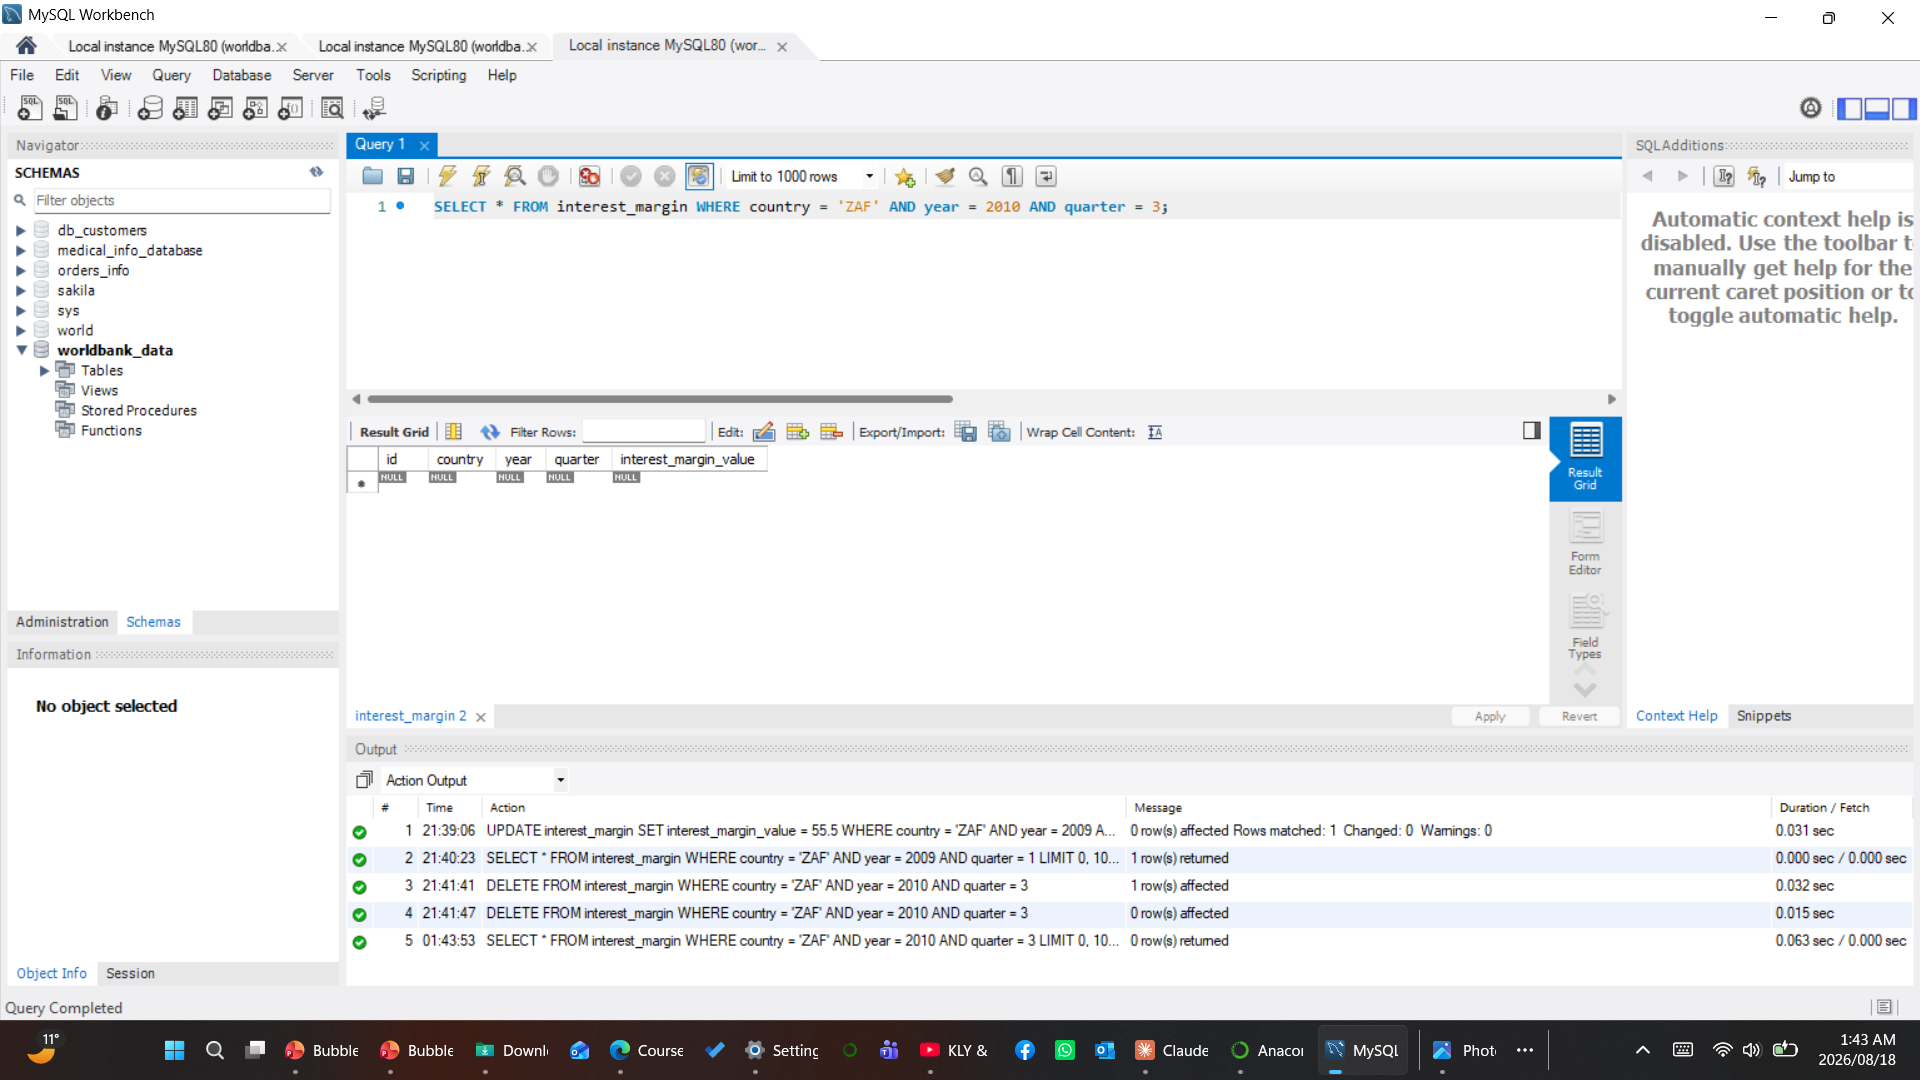

In [82]:
from IPython.display import Image
Image(filename="Screenshot (28).png", width=1000)

**Figure 4.8 — Empty result set confirming the South Africa, 2010 quarter 3 record was successfully deleted from interest_margin.**

## **Step 9: Load the database data back into Pandas**

In [83]:
def db_to_dataframe(conn, table_name):
    """Load a database table back into a Pandas DataFrame."""
    try:
        return pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    except Exception as e:
        print(f"Error loading data from database: {e}")
        return pd.DataFrame()

interest_margin_db_df = db_to_dataframe(conn, "interest_margin")
agri_indicators_db_df = db_to_dataframe(conn, "agri_indicators")

print(interest_margin_db_df.shape)
interest_margin_db_df.head()

(47210, 5)


,id,country,year,quarter,interest_margin_value
0,1,MUS,2009,NaN,69.051442
1,2,MUS,2010,NaN,66.750153
2,3,MUS,2011,NaN,65.101696
3,4,MUS,2012,NaN,65.710860
4,5,MUS,2013,NaN,69.549851


 ## **Step 10: Export to CSV**

In [84]:
interest_margin_db_df.to_csv("interest_margin_from_db.csv", index=False)
agri_indicators_db_df.to_csv("agri_indicators_from_db.csv", index=False)
print("Both tables exported to CSV successfully.")

Both tables exported to CSV successfully.


## **Step 11: Close the connection**

In [85]:
conn.close()
print("Database connection closed.")

Database connection closed.


# PART 5: PYTHON/EXCEL DATA ANALYSIS (Q5)

This section is Q5 of the assignment: clean and transform data, apply conditional formatting, create charts, and summarise findings, done in Excel rather than with matplotlib/seaborn as in Part 4. It reuses the same South Africa Interest Margin to Gross Income series cleaned in Part 1 and analysed in Part 3, but performs an independent clean and transform pass and writes the result into an Excel workbook (`Q5_Excel_Analysis.xlsx`) using the companion script `excel_analysis.py` in this same folder.

Variables in this section are prefixed `q5_` so they do not overwrite or depend on any variable used earlier in this notebook.

## Step 1: Load and clean data

In [ ]:
q5_income = pd.read_csv("Interest_margin_to_gross_income.csv")
q5_income.columns = (
    q5_income.columns
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
)

# Filter to South Africa, Annual frequency
q5_sa = q5_income[(q5_income["REF_AREA"] == "ZAF") & (q5_income["FREQ"] == "A")].copy()
q5_sa = q5_sa[["TIME_PERIOD", "OBS_VALUE", "FINANCIAL_SECTOR_LABEL"]].rename(
    columns={
        "TIME_PERIOD": "Year",
        "OBS_VALUE": "Interest_Margin_Pct",
        "FINANCIAL_SECTOR_LABEL": "Sector",
    }
)
q5_sa["Year"] = q5_sa["Year"].astype(int)
q5_sa = q5_sa.sort_values("Year").reset_index(drop=True)
q5_sa["Interest_Margin_Pct"] = q5_sa["Interest_Margin_Pct"].round(2)

print("Missing values:", q5_sa.isnull().sum().sum())
print("Duplicate years:", q5_sa.duplicated(subset=['Year']).sum())
q5_sa = q5_sa.dropna(subset=["Interest_Margin_Pct"]).drop_duplicates(subset=["Year"])
q5_sa

## Step 2: Transform data

In [ ]:
q5_sa["YoY_Change_pct"] = q5_sa["Interest_Margin_Pct"].pct_change().mul(100).round(2)

def q5_risk_band(value):
    if value < 48:
        return "Low"
    elif value < 54:
        return "Medium"
    else:
        return "High"

q5_sa["Margin_Band"] = q5_sa["Interest_Margin_Pct"].apply(q5_risk_band)
q5_sa

In [ ]:
q5_sa["Margin_Band"].value_counts()

## Step 3: Export to Excel, apply conditional formatting, build charts

The full build (workbook creation, conditional formatting rules, and all three charts) lives in `excel_analysis.py` in this same folder so it can be run again from the command line. Run it directly:

In [ ]:
!python excel_analysis.py

### Conditional formatting applied (in Excel)
- **Colour scale** (green to yellow to red) on `Interest_Margin_Pct`, to flag low vs high values at a glance
- **Red / blue highlight** on `YoY_Change_pct`. Red means the margin rose that year, blue means it fell
- **Red highlight** on rows where `Margin_Band` is "High" (54% and above)

### Charts built (in Excel)
- Trend chart: area filled line, 2008 to 2024, with callouts on the start (2008), low (2010), and high (2024) points
- Year over year change bar chart: red/blue bars matching the same rising/falling logic, with value labels
- Pie chart: share of the 17 years spent in each Margin_Band (Low, Medium, High)

Screenshot of the finished `Q5_Excel_Analysis.xlsx` workbook:

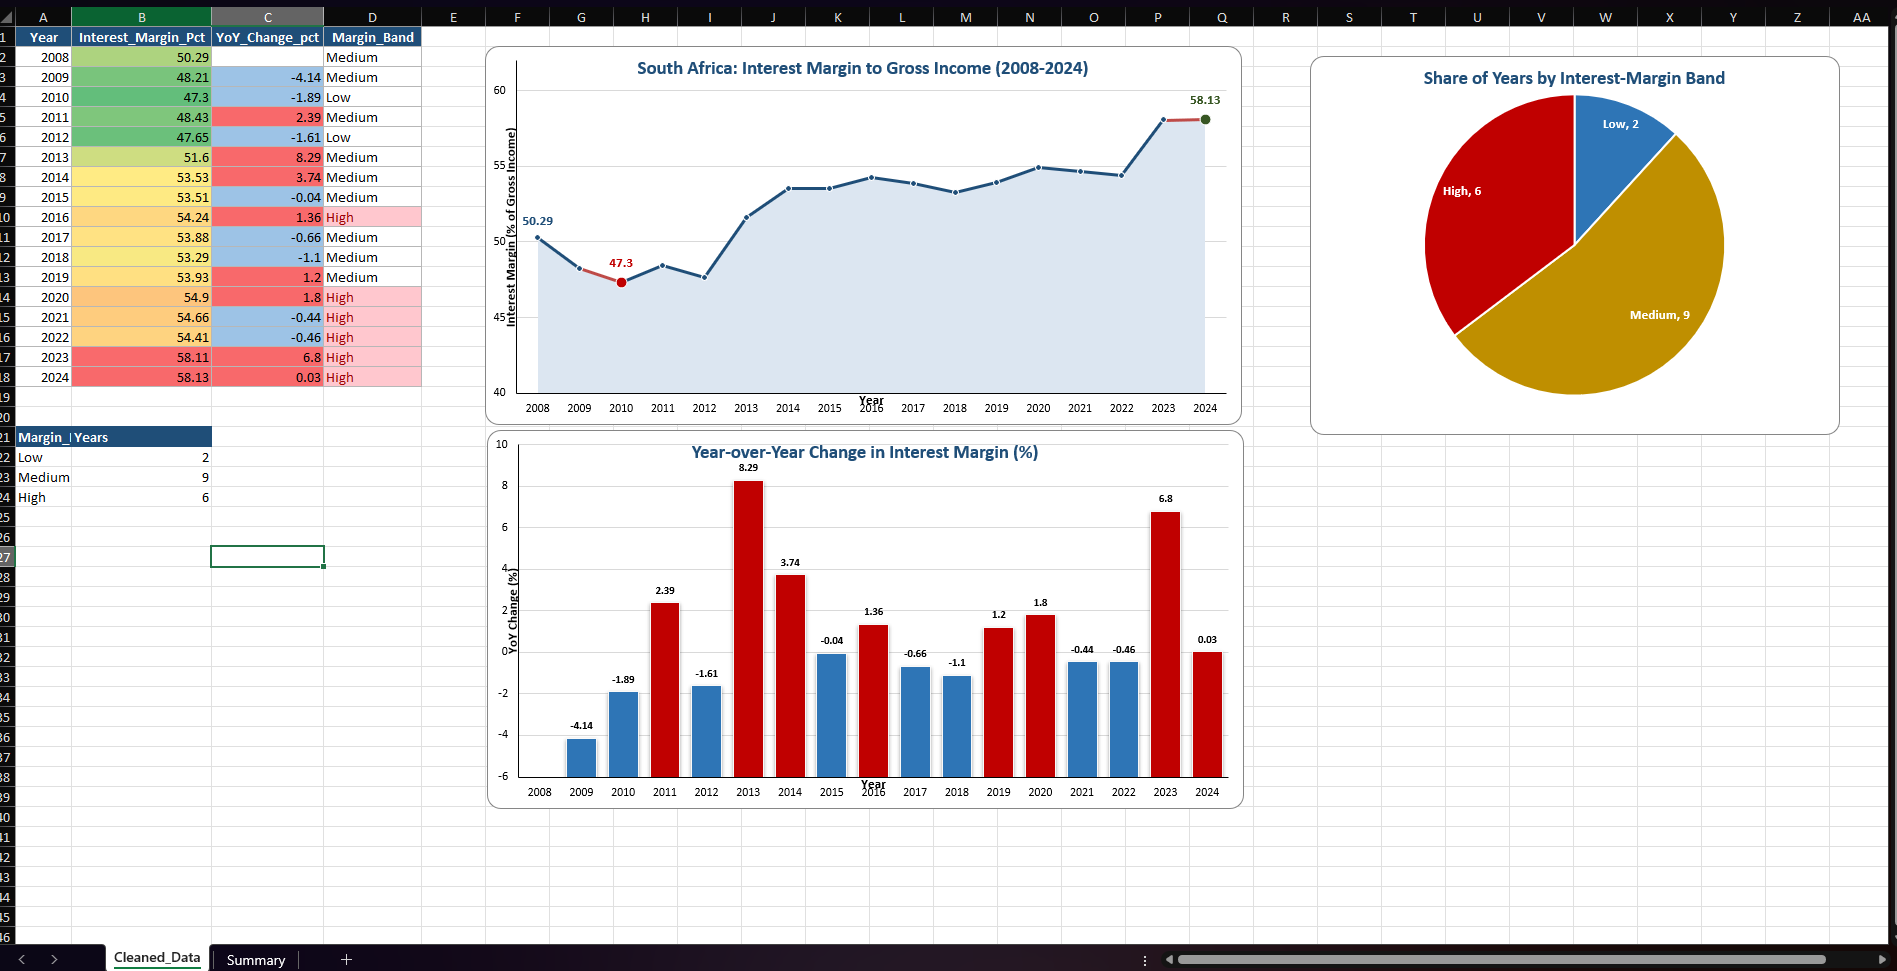

In [1]:
from IPython.display import Image
Image(filename="Screenshot (29).png", width=1200)

## Step 4: Summary of findings

- **Lowest value:** 47.30% in 2010. This is the smallest share of gross income from interest in the period, following the 2008 financial crisis.
- **Highest value:** 58.13% in 2024. The most recent year in the series is also the highest.
- **Overall trend:** rose from 50.29% in 2008 to 58.13% in 2024, a net increase of 7.84 percentage points. It dipped from 2009 to 2012, levelled off around 53% to 55% from 2013 to 2022, then jumped again in 2023 and 2024.
- **Average:** 52.71% across the full period.
- **Margin band distribution:** of the 17 years, 2 fall in the Low band, 9 in Medium, and 6 in High. The High band is concentrated in the most recent years (2016 onward), showing the shift toward higher interest reliance is a recent development rather than something spread evenly across the whole period.
- **Interpretation:** a rising interest margin to gross income ratio suggests South African deposit taking banks have become more dependent on interest based income relative to other income sources (fees, trading, etc.) over this period, especially since 2023. This matches the trend and quarterly analysis and visualisations earlier in this notebook.